# GLBL 570 · Week 7 — Fundamentals of GIS & Mapping: Companion Notebook

This notebook redoes every GIS operation from `GLBL570_Week7_v3.pptx` in Python, using the class data pack `us_census_gis_lab 2/` (U.S. counties + ACS 2018–2022 + USGS 2025 earthquakes).
**Sections follow the order of the slides.** Each heading names the slide(s) it belongs to, and each QGIS step from `README_CN.md` appears next to the slide that introduces the concept.

| Notebook section | Slides | What you do with the data | QGIS lab step (README) |
|---|---|---|---|
| 1 What is GIS? | 4–7 | Open a layer: geometry + attribute table; one county as an "object" | 0–10′ load data |
| 2 Why space matters | 8–12 | Same data as a table/chart vs. as a map; pattern → hypothesis | — |
| 3 Geospatial data | 13–26 | Points/lines/polygons, attribute table, raster, table join, lat/lon → points, file formats, metadata, layers | 0–10′ attribute table + join |
| 4 Coordinate systems & projections | 27–33 | Degrees vs. metres, datums, Plate Carrée, 4269 vs 3857 vs 5070, distortion, choosing a CRS | 25–35′ projections |
| 5 Cartographic design | 34–41 | Map purpose, map elements, vector/raster symbology, pie charts, colour schemes, classification | 10–25′ classification, 35–45′ pie charts |
| 7 Critical & ethical perspectives | 42–49 | Class breaks, colour direction, projection, normalisation, MAUP, protecting locations, information loss | 10–25′ step 4 (totals vs. density) |
| 8 Discussion | 50–53 | (no data operations) | — |
| 9 Lab & milestone | 54–59 | AI map-brief, final map + export, spatial join summary, Moran's I/LISA, OSINT overlay, workflow memo | 45–60′ spatial statistics |

The slides have no section 6, so the numbering skips from 5 to 7.

**Environment:** `geopandas`, `mapclassify`, `rasterio`, `pyproj`, `scipy`, `matplotlib` (tested with the `py39` conda env).
Run the notebook from the `Global_study_experiments/` folder. All outputs go to `outputs/`.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import mapclassify as mc
import pyogrio
import pyproj
from shapely.geometry import LineString, Polygon

DATA = Path("us_census_gis_lab 2")
GPKG = DATA / "us_census_acs2022.gpkg"
CSV = DATA / "acs2022_county_attributes.csv"
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

SOURCE = ("Sources: U.S. Census Bureau, 2018–2022 ACS 5-Year Estimates; "
          "U.S. Geological Survey Earthquake Catalog.")
RNG = np.random.default_rng(570)          # fixed seed: jitter / permutations are reproducible
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "font.size": 9})
MISSING = {"color": "lightgrey", "hatch": "////", "edgecolor": "0.55", "linewidth": 0.1, "label": "No data"}
# On some conda installs GDAL prints "PROJ: proj_create_from_database ... failed" at import; reprojection still works.
print("geopandas", gpd.__version__, "| mapclassify", mc.__version__, "| pyproj", pyproj.__version__)

geopandas 1.0.1 | mapclassify 2.8.1 | pyproj 3.6.1


ERROR 1: PROJ: proj_create_from_database: Open of /u/wz53/miniconda3/envs/py39/share/proj failed


In [2]:
# Small cartography helpers used throughout (scale bar, north arrow, source line, graticule).
def add_scale_bar(ax, length_km, x=0.04, y=0.05):
    # Valid only when the axes are in a projected CRS with metre units.
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    sx, sy = x0 + x * (x1 - x0), y0 + y * (y1 - y0)
    ax.plot([sx, sx + length_km * 1000], [sy, sy], color="k", lw=3, solid_capstyle="butt")
    ax.text(sx + length_km * 500, sy + 0.015 * (y1 - y0), f"{length_km:,} km", ha="center", va="bottom", fontsize=7)


def add_north_arrow(ax, x=0.95, y=0.88):
    ax.annotate("N", xy=(x, y), xytext=(x, y - 0.09), xycoords="axes fraction", ha="center",
                fontsize=10, fontweight="bold", arrowprops=dict(facecolor="k", width=3, headwidth=9))


def add_source(ax, text=SOURCE):
    ax.annotate(text, xy=(0, -0.01), xycoords="axes fraction", va="top", fontsize=6.5, color="0.35")


def graticule(crs, lons=range(-130, -59, 10), lats=range(20, 56, 5)):
    lines = [LineString([(lo, la) for la in np.linspace(min(lats), max(lats), 60)]) for lo in lons]
    lines += [LineString([(lo, la) for lo in np.linspace(min(lons), max(lons), 120)]) for la in lats]
    return gpd.GeoSeries(lines, crs=4269).to_crs(crs)


REGION = {**dict.fromkeys("CT ME MA NH RI VT NJ NY PA".split(), "Northeast"),
          **dict.fromkeys("IL IN MI OH WI IA KS MN MO NE ND SD".split(), "Midwest"),
          **dict.fromkeys("DE DC FL GA MD NC SC VA WV AL KY MS TN AR LA OK TX".split(), "South"),
          **dict.fromkeys("AZ CO ID MT NV NM UT WY AK CA HI OR WA".split(), "West")}

---
## 1 · What Is GIS? (slides 4–7)

Slide 5 defines GIS as *"a system for capturing, storing, checking, integrating, manipulating, analyzing and displaying spatial data."*
Slide 7 adds that **GIS starts from objects that already have a geometry and an attribute table**, while remote sensing (next week) starts from a signal.
The first step is to open the GeoPackage and look at one of those objects.

**QGIS equivalent:** drag `us_census_acs2022.gpkg` into QGIS and add `us_counties_geometry`.

In [3]:
# A GeoPackage is one file that can hold several layers.
print(pyogrio.list_layers(GPKG))

counties_geom = gpd.read_file(GPKG, layer="us_counties_geometry")   # geometry + IDs only (for the join exercise)
counties = gpd.read_file(GPKG, layer="us_counties_acs2022")         # already joined with ACS attributes
quakes = gpd.read_file(GPKG, layer="usgs_earthquakes_2025_m25")     # USGS points, M >= 2.5, year 2025
quakes["depth_km"] = quakes.geometry.z                               # 3-D points: z = depth (km)
for name, g in [("us_counties_geometry", counties_geom), ("us_counties_acs2022", counties), ("usgs_earthquakes_2025_m25", quakes)]:
    print(f"{name:28s} rows={len(g):5d}  cols={g.shape[1]:3d}  geometry={g.geom_type.unique()}  CRS={g.crs.to_string()}")

[['us_counties_acs2022' 'MultiPolygon']
 ['us_counties_geometry' 'MultiPolygon']
 ['usgs_earthquakes_2025_m25' 'Point Z']]


us_counties_geometry         rows= 3144  cols= 10  geometry=['MultiPolygon']  CRS=EPSG:4269
us_counties_acs2022          rows= 3144  cols= 33  geometry=['MultiPolygon']  CRS=EPSG:4269
usgs_earthquakes_2025_m25    rows= 3754  cols= 22  geometry=['Point']  CRS=EPSG:4979


### 1.1 One GIS object = one geometry + one row of attributes (slide 7)
This example uses Champaign County, IL (`GEOID 17019`). The polygon is the *geometry*, and the fields are its *attributes*.

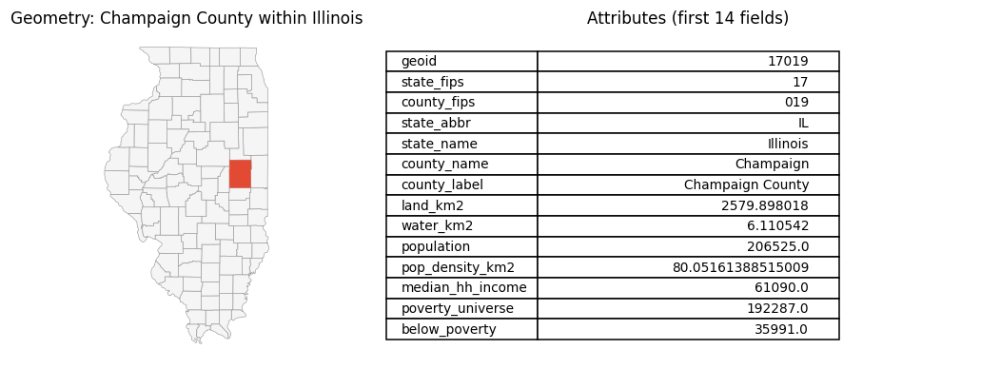

Geometry type: MultiPolygon | vertices: 26 | WKT starts: MULTIPOLYGON (((-88.463634 40.218257, -88.46072 40.223322, -88.460418 40.281935, ...


In [4]:
champaign = counties[counties.geoid == "17019"]
fig, (ax_map, ax_tab) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})
counties[counties.state_fips == "17"].plot(ax=ax_map, color="whitesmoke", edgecolor="0.6", lw=0.4)
champaign.plot(ax=ax_map, color="#e34a33")
ax_map.set_title("Geometry: Champaign County within Illinois"); ax_map.set_axis_off()

row = champaign.drop(columns="geometry").T.iloc[:14]
ax_tab.axis("off"); ax_tab.set_title("Attributes (first 14 fields)")
ax_tab.table(cellText=row.values, rowLabels=row.index, loc="center", colWidths=[0.5]).scale(1, 1.05)
plt.tight_layout(); plt.show()

geom = champaign.geometry.iloc[0]
print("Geometry type:", geom.geom_type, "| vertices:", len(geom.geoms[0].exterior.coords), "| WKT starts:", geom.wkt[:80], "...")

---
## 2 · Why Space Matters (slides 8–12)

Slide 10 asks: *why might a map tell a different story than a chart?* A table ranks places, while a map shows their neighbours, clusters, and corridors.
The next cells put the same variable (`poverty_pct`) into a ranked chart and then into a map.

### 2.1 The table/chart view: a ranking with no geography

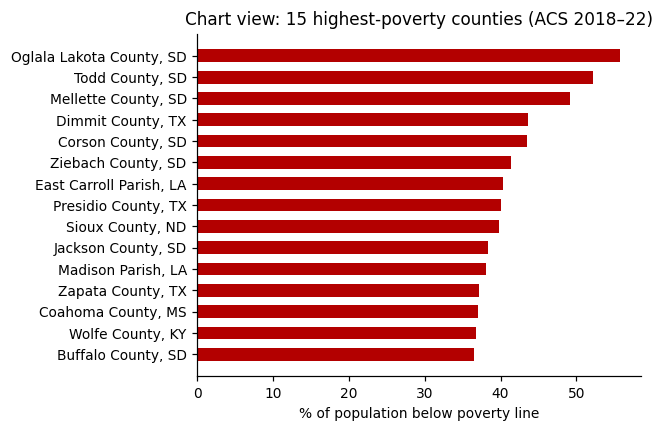

In [5]:
top = counties.nlargest(15, "poverty_pct")[["county_label", "state_abbr", "poverty_pct", "population"]]
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top.county_label + ", " + top.state_abbr, top.poverty_pct, color="#b30000", height=0.6)
ax.invert_yaxis(); ax.set_xlabel("% of population below poverty line")
ax.set_title("Chart view: 15 highest-poverty counties (ACS 2018–22)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 2.2 The map view: the same numbers reveal clusters
The highest-poverty 5% of counties are outlined below. In the chart they were a list. On the map they form regions: the Mississippi Delta, Appalachia, the Rio Grande border, the Black Belt, and reservation counties in the Dakotas.
(The map uses the Albers equal-area projection, which §4 explains.)

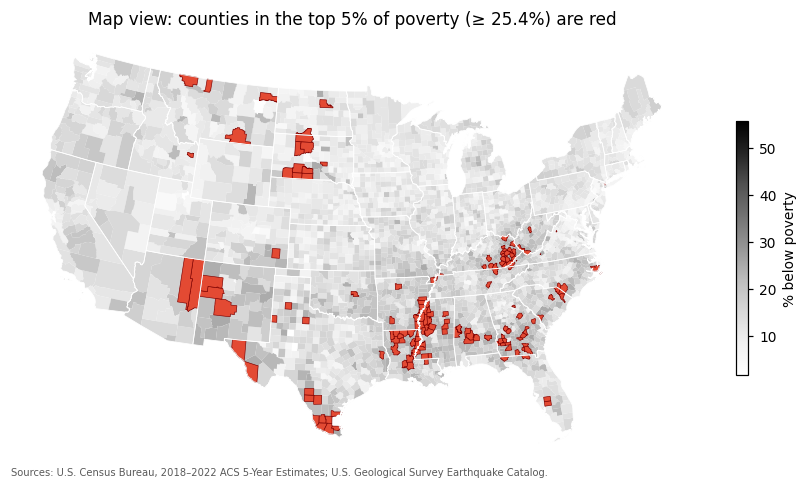

States holding the top-5% counties:
{'MS': 21, 'KY': 21, 'GA': 20, 'LA': 17, 'TX': 16, 'SD': 9, 'AR': 7, 'AL': 7, 'SC': 5, 'FL': 4}


In [6]:
lower48 = counties[~counties.state_abbr.isin(["AK", "HI"])].to_crs(5070)
states = counties.dissolve(by="state_abbr", aggfunc={"state_name": "first", "population": "sum",
                                                     "below_poverty": "sum", "poverty_universe": "sum"}).reset_index()
states48 = states[~states.state_abbr.isin(["AK", "HI"])].to_crs(5070)

thr = counties.poverty_pct.quantile(0.95)
fig, ax = plt.subplots(figsize=(10, 6))
lower48.plot(ax=ax, column="poverty_pct", cmap="Greys", lw=0, legend=True,
             legend_kwds={"shrink": 0.5, "label": "% below poverty"})
lower48[lower48.poverty_pct >= thr].plot(ax=ax, facecolor="#e34a33", edgecolor="#7f0000", lw=0.4)
states48.boundary.plot(ax=ax, color="white", lw=0.5)
ax.set_title(f"Map view: counties in the top 5% of poverty (≥ {thr:.1f}%) are red"); ax.set_axis_off()
add_source(ax); plt.show()

print("States holding the top-5% counties:")
print(counties[counties.poverty_pct >= thr].state_abbr.value_counts().head(10).to_dict())

### 2.3 Pattern → hypothesis → test (slide 11, "Poverty in remote areas")
Slide 11's chain: **pattern** (poverty clusters where access is poor) → **hypothesis** (low accessibility → fewer opportunities) → **test**.
The data pack has no travel-time layer, so population density stands in as a rough proxy for accessibility. Treat the result as a first look, not a test: a correlation is not causal, and density is not accessibility.
§9.4 tests the "clusters" part formally with Moran's I.

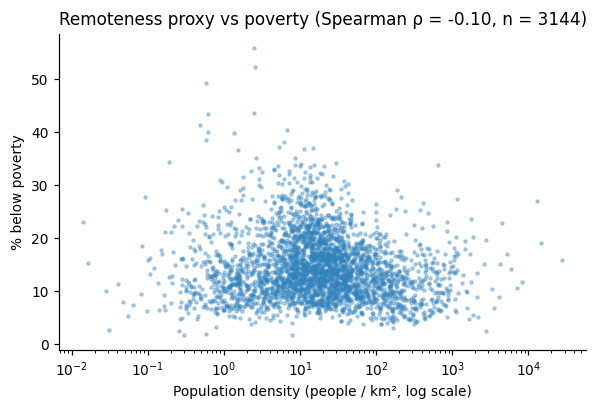

In [7]:
d = counties[["poverty_pct", "pop_density_km2"]].dropna()
rho = d.corr(method="spearman").iloc[0, 1]
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.scatter(d.pop_density_km2, d.poverty_pct, s=4, alpha=0.35, color="#3182bd")
ax.set_xscale("log"); ax.set_xlabel("Population density (people / km², log scale)"); ax.set_ylabel("% below poverty")
ax.set_title(f"Remoteness proxy vs poverty (Spearman ρ = {rho:.2f}, n = {len(d)})")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()

### 2.4 Snow 1854 → today: a spatial pattern drives the decision (slides 10, 12)
John Snow mapped cholera deaths as points and saw that they clustered around one water pump. The same kind of point-pattern reading works on the 2025 earthquake catalogue: the points cluster along known structures (the Pacific margin, the Alaska subduction zone) and also in places that suggest induced seismicity (Oklahoma, west Texas).

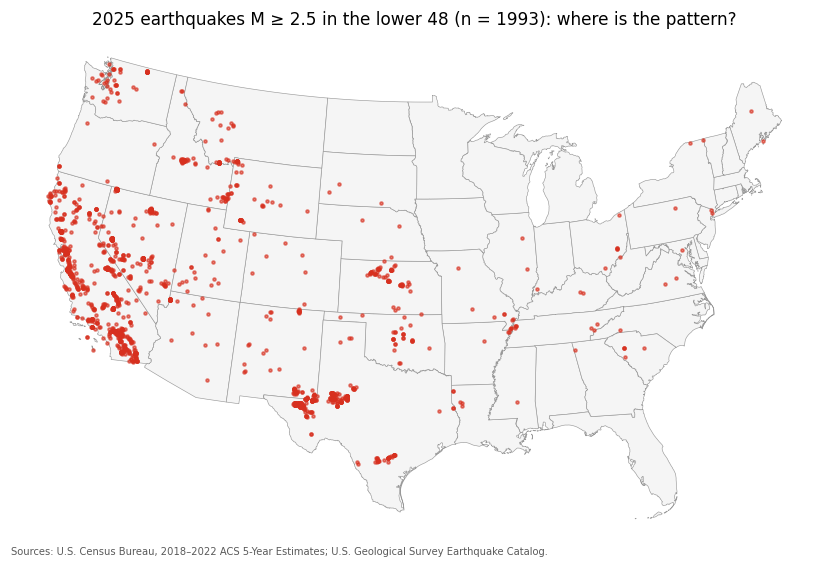

In [8]:
q48 = quakes.to_crs(5070).clip(states48.total_bounds)
fig, ax = plt.subplots(figsize=(10, 6))
states48.plot(ax=ax, color="whitesmoke", edgecolor="0.6", lw=0.4)
q48.plot(ax=ax, markersize=4, color="#d7301f", alpha=0.6)
ax.set_title(f"2025 earthquakes M ≥ 2.5 in the lower 48 (n = {len(q48)}): where is the pattern?"); ax.set_axis_off()
add_source(ax); plt.show()

---
## 3 · Geospatial Data (slides 13–26)

### 3.1 Vector data: points, lines, polygons (slides 14–16)
Vectors are built from coordinates. The data pack contains **points** (earthquakes) and **polygons** (counties). A **line** layer can be derived by turning the state polygons into their boundary lines.

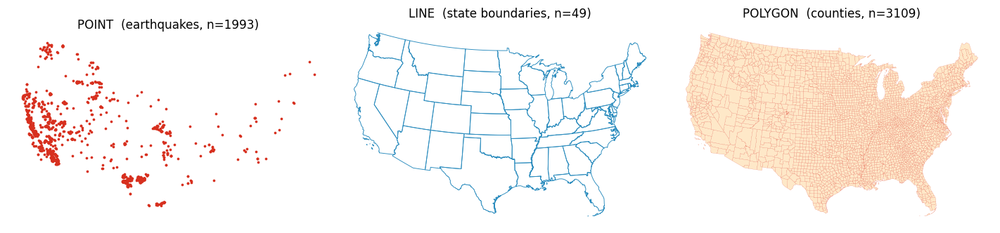

Geometry types: ['Point'] ['MultiLineString' 'LineString'] ['MultiPolygon']
Earthquake points are 3-D: z = depth (km). Example: POINT Z (-119.215 38.7512 10.4)


In [9]:
state_lines = states48.boundary                       # polygon -> line
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
q48.plot(ax=axes[0], markersize=2, color="#d7301f");                     axes[0].set_title(f"POINT  (earthquakes, n={len(q48)})")
state_lines.plot(ax=axes[1], color="#2b8cbe", lw=0.6);                  axes[1].set_title(f"LINE  (state boundaries, n={len(state_lines)})")
lower48.plot(ax=axes[2], color="#fee8c8", edgecolor="#e34a33", lw=0.1); axes[2].set_title(f"POLYGON  (counties, n={len(lower48)})")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()
print("Geometry types:", quakes.geom_type.unique(), state_lines.geom_type.unique(), counties.geom_type.unique())
print("Earthquake points are 3-D: z = depth (km). Example:", quakes.geometry.iloc[0])

### 3.2 The attribute table (slide 17)
Vectors have a front-end **geometry** and a back-end database, the **attribute table**: *rows = unique geometries, columns = variables.*
**QGIS equivalent:** right-click the layer → *Open Attribute Table*.

In [10]:
attr = counties.drop(columns="geometry")
print(f"{attr.shape[0]} rows (one per county)  ×  {attr.shape[1]} columns (variables)")
display(attr.head())
print(attr.dtypes.value_counts().to_dict())

3144 rows (one per county)  ×  32 columns (variables)


,geoid,state_fips,county_fips,state_abbr,state_name,county_name,county_label,land_km2,water_km2,population,...,commuters_total,commute_drive_alone,commute_carpool,commute_transit,commute_bicycle,commute_walk,commute_other,commute_wfh,transit_pct,wfh_pct
0,13233,13,233,GA,Georgia,Polk,Polk County,803.775591,4.664760,43019.0,...,17896.0,14743.0,1698.0,76.0,16.0,209.0,331.0,823.0,0.424676,4.598793
1,21023,21,023,KY,Kentucky,Bracken,Bracken County,524.900457,16.279752,8420.0,...,3557.0,2767.0,489.0,12.0,0.0,45.0,48.0,196.0,0.337363,5.510261
2,28153,28,153,MS,Mississippi,Wayne,Wayne County,2099.745602,7.255476,19760.0,...,7398.0,6193.0,572.0,0.0,0.0,132.0,228.0,273.0,0.000000,3.690187
3,42001,42,001,PA,Pennsylvania,Adams,Adams County,1343.400757,7.771555,104604.0,...,50568.0,39984.0,3897.0,113.0,198.0,1764.0,297.0,4315.0,0.223461,8.533064
4,04007,04,007,AZ,Arizona,Gila,Gila County,12322.070148,96.465330,53419.0,...,18434.0,13518.0,2658.0,7.0,37.0,391.0,195.0,1628.0,0.037973,8.831507


{dtype('float64'): 25, dtype('O'): 7}


### 3.3 Raster data: a georeferenced cell matrix (slides 18–19)
A raster stores **one value per cell**, and each cell maps to a real-world location. One band symbolises one variable at a time.
The data pack ships only vector data, so the cells below *rasterise* county population density onto a 20 km grid. This shows how a cell matrix differs from polygons.
(The grid is in EPSG:5070 so that every cell is 20 km × 20 km on the ground; §4 explains why.)

Raster: 146 rows × 231 cols, cell = 20 km, valid cells = 19,537
Georeferencing (affine transform): | 20000.00, 0.00,-2356113.74|
| 0.00,-20000.00, 3172567.92|
| 0.00, 0.00, 1.00|


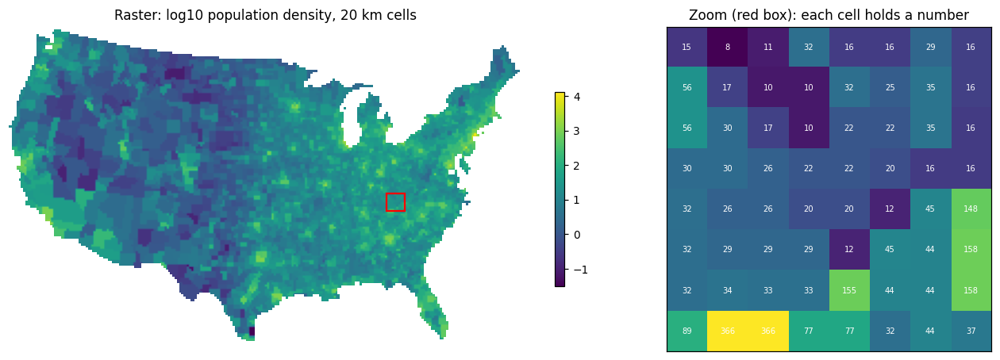

In [11]:
import rasterio
from rasterio import features
from rasterio.transform import from_origin

RES = 20_000                                            # 20 km cells
minx, miny, maxx, maxy = lower48.total_bounds
W, H = int(np.ceil((maxx - minx) / RES)), int(np.ceil((maxy - miny) / RES))
TRANSFORM = from_origin(minx, maxy, RES, RES)
EXTENT = (minx, minx + W * RES, maxy - H * RES, maxy)


def rasterize(col):
    shapes = ((g, v) for g, v in zip(lower48.geometry, lower48[col]))
    return features.rasterize(shapes, out_shape=(H, W), transform=TRANSFORM, fill=np.nan, dtype="float32")


dens = rasterize("pop_density_km2")
with rasterio.open(OUT / "pop_density_20km_epsg5070.tif", "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="float32", crs="EPSG:5070", transform=TRANSFORM, nodata=np.nan) as dst:
    dst.write(dens, 1)
print(f"Raster: {H} rows × {W} cols, cell = {RES/1000:.0f} km, valid cells = {np.isfinite(dens).sum():,}")
print("Georeferencing (affine transform):", TRANSFORM)

r0, c0 = 75, 170                                        # an 8×8 window around the Chicago area
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
im = a1.imshow(np.log10(dens), extent=EXTENT, cmap="viridis"); a1.set_axis_off()
a1.add_patch(plt.Rectangle((minx + c0 * RES, maxy - (r0 + 8) * RES), 8 * RES, 8 * RES, fill=False, color="red", lw=1.5))
a1.set_title("Raster: log10 population density, 20 km cells"); fig.colorbar(im, ax=a1, shrink=0.6)
win = dens[r0:r0 + 8, c0:c0 + 8]
a2.imshow(np.log10(win), cmap="viridis"); a2.set_title("Zoom (red box): each cell holds a number")
for (i, j), v in np.ndenumerate(win):
    a2.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6.5, color="w")
a2.set_xticks([]); a2.set_yticks([]); plt.tight_layout(); plt.show()

**Categorical rasters and the value attribute table (slide 19).** An integer raster can carry a *value attribute table*, with one row per unique value rather than one row per feature.

In [12]:
BREAKS, LABELS = [0, 10, 50, 250, np.inf], ["Rural (<10/km²)", "Low (10–50)", "Medium (50–250)", "Urban (≥250)"]
dens_cls = np.where(np.isfinite(dens), np.digitize(dens, BREAKS[1:-1]) + 1, 0).astype("uint8")   # 0 = nodata
vals, n = np.unique(dens_cls[dens_cls > 0], return_counts=True)
vat = pd.DataFrame({"value": vals, "label": [LABELS[v - 1] for v in vals], "cell_count": n,
                    "area_km2": n * (RES / 1000) ** 2})
display(vat)

,value,label,cell_count,area_km2
0,1,Rural (<10/km²),10461,4184400.0
1,2,Low (10–50),6089,2435600.0
2,3,Medium (50–250),2349,939600.0
3,4,Urban (≥250),638,255200.0


### 3.4 Tabular data → spatial data (slide 20)
Slide 20 names two routes: **(1) joining** on a shared unique identifier, and **(2) geocoding** lat/lon coordinates (or addresses).

#### (1) Attribute join: `GEOID = geoid`
**QGIS equivalent:** add the CSV as *delimited text, no geometry*, then *Layer Properties → Joins*, `GEOID = geoid`.
The README warns that the `.csvt` file must sit next to the CSV, or GEOID loses its leading zeros. The next cell reproduces that failure.

In [13]:
bad = pd.read_csv(CSV)                                  # no type hints -> geoid becomes an integer
print("Without type hints, geoid dtype =", bad.geoid.dtype, "| Autauga County, AL:", bad.geoid[bad.county_name == "Autauga"].tolist())
matched = bad.geoid.astype(str).isin(counties_geom.GEOID)
print(f"Rows that still match a GEOID: {matched.sum()} / {len(bad)}")
print("States that silently drop out of the join:", sorted(bad.loc[~matched, "state_abbr"].unique()))

Without type hints, geoid dtype = int64 | Autauga County, AL: [1001]
Rows that still match a GEOID: 2826 / 3144
States that silently drop out of the join: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT']


In [14]:
# Fix: read the key columns as text (the .csvt file does the same in QGIS).
csvt = (DATA / "acs2022_county_attributes.csvt").read_text().strip().replace('"', "").split(",")
dtypes = {c: (str if t == "String" else float) for c, t in zip(pd.read_csv(CSV, nrows=0).columns, csvt)}
attrs = pd.read_csv(CSV, dtype=dtypes)

joined = counties_geom.merge(attrs, left_on="GEOID", right_on="geoid", how="left", validate="1:1", indicator=True)
print(joined["_merge"].value_counts().to_dict())
print("Rows after join:", len(joined), "(README expects 3,144)")
check = joined.set_index("geoid")[["poverty_pct", "population"]].sort_index()
ref = counties.set_index("geoid")[["poverty_pct", "population"]].sort_index()
print("Identical to the pre-joined layer us_counties_acs2022:", np.allclose(check.values, ref.values, equal_nan=True))

{'both': 3144, 'left_only': 0, 'right_only': 0}
Rows after join: 3144 (README expects 3,144)
Identical to the pre-joined layer us_counties_acs2022: True


#### (2) Geocoding from lat/lon columns
Here the earthquake layer is exported to a plain table with `longitude, latitude` columns and then turned back into points. (Geocoding *addresses* requires a street-network service and is not shown.)

In [15]:
eq_table = pd.DataFrame({"id": quakes.id, "mag": quakes.mag,
                         "longitude": quakes.geometry.x, "latitude": quakes.geometry.y})
eq_table.to_csv(OUT / "earthquakes_table.csv", index=False)
print(eq_table.head(3))

eq_pts = gpd.GeoDataFrame(eq_table, geometry=gpd.points_from_xy(eq_table.longitude, eq_table.latitude), crs="EPSG:4326")
print("Rebuilt", len(eq_pts), "points; CRS =", eq_pts.crs.to_string(),
      "| same locations as source:", np.allclose(eq_pts.geometry.x, quakes.geometry.x))

           id  mag  longitude  latitude
0  nn00891080  2.6  -119.2150   38.7512
1  us6000pmej  3.2  -169.0457   52.7864
2  us6000pgsn  2.5   -74.4804   44.9207
Rebuilt 3754 points; CRS = EPSG:4326 | same locations as source: True


### 3.5 File formats: reading and exporting (slides 21–23)
GIS reads `.csv` and `.dbf` (a shapefile's attribute table). QGIS cannot read `.xlsx`, so save Excel sheets as CSV first.
GIS can also export to many formats. Each format below carries a cost:
- **Shapefile** is really 4–6 sidecar files, and its `.dbf` truncates field names to 10 characters.
- **KML** is forced into WGS 84.
- **GeoJSON** is plain text and large.

In [16]:
il = counties[counties.state_fips == "17"]
shp_dir = OUT / "shapefile"; shp_dir.mkdir(exist_ok=True)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                    # pyogrio warns about the truncated names below
    il.to_file(shp_dir / "il_counties.shp")
il.to_file(OUT / "il_counties.geojson", driver="GeoJSON")
il.to_crs("OGC:CRS84")[["county_label", "population", "geometry"]].to_file(OUT / "il_counties.kml", driver="KML")  # KML = lon/lat WGS 84
il.to_file(OUT / "il_counties.gpkg", layer="il_counties")

files = sorted(shp_dir.iterdir()) + [OUT / "il_counties.geojson", OUT / "il_counties.kml", OUT / "il_counties.gpkg"]
display(pd.DataFrame({"file": [f.name for f in files], "size_kB": [round(f.stat().st_size / 1024, 1) for f in files]}))

dbf = gpd.read_file(shp_dir / "il_counties.dbf")       # the .dbf alone is just a table
long_names = [c for c in il.columns if len(c) > 10]
print("Field names truncated by the .dbf:", dict(zip(long_names, [c for c in dbf.columns if c not in il.columns])))

,file,size_kB
0,il_counties.cpg,0.0
1,il_counties.dbf,116.7
2,il_counties.prj,0.2
3,il_counties.shp,83.6
4,il_counties.shx,0.9
5,il_counties.geojson,230.7
6,il_counties.kml,248.1
7,il_counties.gpkg,224.0


Field names truncated by the .dbf: {'county_fips': 'county_fip', 'county_name': 'county_nam', 'county_label': 'county_lab', 'pop_density_km2': 'pop_densit', 'median_hh_income': 'median_hh_', 'poverty_universe': 'poverty_un', 'below_poverty': 'below_pove', 'poverty_pct': 'poverty_pc', 'race_two_plus': 'race_two_p', 'commuters_total': 'commuters_', 'commute_drive_alone': 'commute_dr', 'commute_carpool': 'commute_ca', 'commute_transit': 'commute_tr', 'commute_bicycle': 'commute_bi', 'commute_walk': 'commute_wa', 'commute_other': 'commute_ot', 'commute_wfh': 'commute_wf', 'transit_pct': 'transit_pc'}


### 3.6 Metadata (slide 24)
Metadata describe **content, structure, quality, lineage, and usage constraints**. Some of it can be read from the file. Quality has to be checked, and here the check finds a real problem.

In [17]:
info = pyogrio.read_info(GPKG, layer="us_counties_acs2022")
print({k: info[k] for k in ["crs", "geometry_type", "features"]}, "| bounds:", np.round(info["total_bounds"], 2))

# Quality check: summary statistics reveal a Census sentinel value hiding in median_hh_income.
display(counties[["population", "median_hh_income", "poverty_pct", "pop_density_km2"]].describe().T[["min", "50%", "max"]])
bad_inc = counties[counties.median_hh_income < 0]
print("Negative median income (ACS 'not available' code):", bad_inc[["county_label", "state_abbr", "median_hh_income"]].values.tolist())

{'crs': 'EPSG:4269', 'geometry_type': 'MultiPolygon', 'features': 3144} | bounds: [-179.15   18.92  179.78   71.35]


,min,50%,max
population,5.000000e+01,25784.500000,9.936690e+06
median_hh_income,-6.666667e+08,60931.000000,1.704630e+05
poverty_pct,1.603499e+00,13.398556,5.577648e+01
pop_density_km2,1.420278e-02,17.271909,2.804632e+04


Negative median income (ACS 'not available' code): [['Loving County', 'TX', -666666666.0]]


In [18]:
# Set the sentinel to missing. If it stayed, this county would be drawn as the poorest place in America.
for g in (counties, lower48):
    g.loc[g.median_hh_income < 0, "median_hh_income"] = np.nan

# Structure checks promised by the README: category counts must sum to their totals.
race = [c for c in counties.columns if c.startswith("race_")]
commute = [c for c in counties.columns if c.startswith("commute_")]
print("race_* sums to population for all counties:   ", np.allclose(counties[race].sum(1), counties.population))
print("commute_* sums to commuters_total for all:      ", np.allclose(counties[commute].sum(1), counties.commuters_total))

metadata = {
    "title": "U.S. counties with ACS 2018–2022 attributes and 2025 USGS earthquakes (GLBL 570 teaching pack)",
    "content": "3,144 counties/county equivalents (50 states + DC); 3,754 earthquakes M>=2.5 in 2025",
    "structure": {"crs_counties": str(counties.crs), "crs_quakes": str(quakes.crs), "fields": list(attr.columns)},
    "quality": ["ACS values are survey estimates; margins of error not included in this pack",
                "1 county had median_hh_income = -666666666 (not available) -> set to NaN",
                "Boundaries are 1:5,000,000 cartographic; areas come from detailed TIGER, not the simplified geometry"],
    "lineage": ["Census TIGER/Line 2022 + ACS 5-year (B02001, B19013, B17001, B08301)",
                "USGS FDSN catalog 2025-01-01..2026-01-01, M>=2.5, clipped to county boundaries"],
    "constraints": "Teaching use; not for cadastral/engineering area work; earthquakes are one year only",
}
(OUT / "metadata_record.json").write_text(json.dumps(metadata, indent=2))
print("Wrote", OUT / "metadata_record.json")

race_* sums to population for all counties:    True
commute_* sums to commuters_total for all:       True
Wrote outputs/metadata_record.json


### 3.7 Understanding data "layers" (slides 25–26)
A map is a stack of layers, like the Google Maps example: background, then land use, then streets, then points of interest. The panels below build a map one layer at a time, with drawing order set by `zorder`.

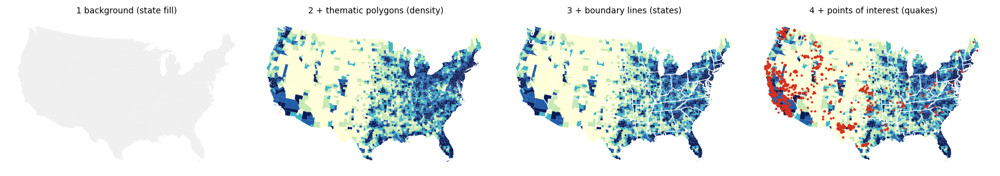

In [19]:
layers = [
    ("1 background (state fill)", lambda ax: states48.plot(ax=ax, color="#f0f0f0", zorder=1)),
    ("2 + thematic polygons (density)", lambda ax: lower48.plot(ax=ax, column="pop_density_km2", scheme="Quantiles", k=5,
                                                                cmap="YlGnBu", lw=0, zorder=2)),
    ("3 + boundary lines (states)", lambda ax: state_lines.plot(ax=ax, color="white", lw=0.6, zorder=3)),
    ("4 + points of interest (quakes)", lambda ax: q48.plot(ax=ax, markersize=2, color="#d7301f", zorder=4)),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for i, ax in enumerate(axes):
    for _, draw in layers[: i + 1]:
        draw(ax)
    ax.set_title(layers[i][0], fontsize=9); ax.set_axis_off()
plt.tight_layout(); plt.show()

---
## 4 · Coordinate Systems & Projections (slides 27–33)

### 4.1 Geographic vs projected coordinate systems (slides 28–29)
A **geographic CRS** uses angular units (degrees) on a spheroid, so lengths and areas change with latitude. A **projected CRS** uses linear units (metres) on a plane.
The test below measures area in the wrong system and in the right one.

EPSG:4269 axis units: degree | EPSG:5070 axis units: metre


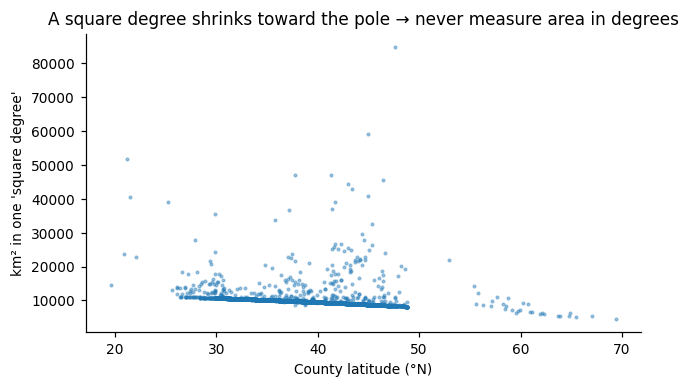

,county_label,state_abbr,area_sq_degrees,area_km2_albers,official_km2
384,Yukon-Koyukuk Census Area,AK,74.26,383026.79,382983.69
73,North Slope Borough,AK,53.18,233919.38,245603.18


In [20]:
print("EPSG:4269 axis units:", counties.crs.axis_info[0].unit_name, "| EPSG:5070 axis units:", pyproj.CRS(5070).axis_info[0].unit_name)

cmp = counties[["county_label", "state_abbr", "land_km2", "water_km2"]].copy()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                    # geopandas warns: area in a geographic CRS is meaningless
    cmp["area_sq_degrees"] = counties.geometry.area
cmp["area_km2_albers"] = counties.to_crs(5070).area / 1e6
cmp["official_km2"] = cmp.land_km2 + cmp.water_km2
cmp["lat"] = counties.to_crs(5070).centroid.to_crs(4269).y
cmp["km2_per_sq_degree"] = cmp.official_km2 / cmp.area_sq_degrees

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.scatter(cmp.lat, cmp.km2_per_sq_degree, s=3, alpha=0.4)
ax.set_xlabel("County latitude (°N)"); ax.set_ylabel("km² in one 'square degree'")
ax.set_title("A square degree shrinks toward the pole → never measure area in degrees")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()
display(cmp.loc[cmp.state_abbr.isin(["TX", "AK"])].nlargest(2, "official_km2")[
    ["county_label", "state_abbr", "area_sq_degrees", "area_km2_albers", "official_km2"]].round(2))

### 4.2 Datums: NAD83 vs WGS 84 (slide 30)
Each geographic CRS chooses an ellipsoid and an anchor (the datum). The counties use **NAD83 (EPSG:4269)** and the earthquakes use **WGS 84 3-D (EPSG:4979)**. QGIS reprojects on the fly; in code it must be done explicitly.

In [21]:
print("Counties:", counties.crs.name, "| datum:", counties.crs.datum.name)
print("Quakes:  ", quakes.crs.name, "| datum:", quakes.crs.datum.name)
quakes = quakes.to_crs(4269)                                     # one CRS for all analysis layers
for src in (4267, 4979):                                         # NAD27 and WGS 84 (3-D) -> NAD83
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                          # pyproj warns that the grid files are not installed
        group = pyproj.transformer.TransformerGroup(src, 4269)
    print(f"EPSG:{src} -> NAD83: {len(group.transformers)} usable operation(s); best = {group.transformers[0].description!r}; "
          f"grid files missing for {len(group.unavailable_operations)} more accurate one(s)")
print("Note: NAD27 -> NAD83 shifts of tens of metres need NADCON grids; without them PROJ falls back to a ballpark shift.")
print("WGS 84 -> NAD83 differ by ~1-2 m today; PROJ's default treats them as equal, which is fine at county scale.")

Counties: NAD83 | datum: North American Datum 1983
Quakes:   WGS 84 | datum: World Geodetic System 1984 ensemble
EPSG:4267 -> NAD83: 1 usable operation(s); best = 'Ballpark geographic offset from NAD27 to NAD83'; grid files missing for 9 more accurate one(s)
EPSG:4979 -> NAD83: 4 usable operation(s); best = 'Inverse of NAD83 to WGS 84 (1)'; grid files missing for 49 more accurate one(s)
Note: NAD27 -> NAD83 shifts of tens of metres need NADCON grids; without them PROJ falls back to a ballpark shift.
WGS 84 -> NAD83 differ by ~1-2 m today; PROJ's default treats them as equal, which is fine at county scale.


### 4.3 Unprojected display = Plate Carrée (slide 31)
Plotting longitude and latitude directly as x and y produces the equidistant cylindrical (Plate Carrée) map. GeoPandas usually hides this by stretching the aspect ratio; forcing a 1:1 aspect shows the raw geometry.

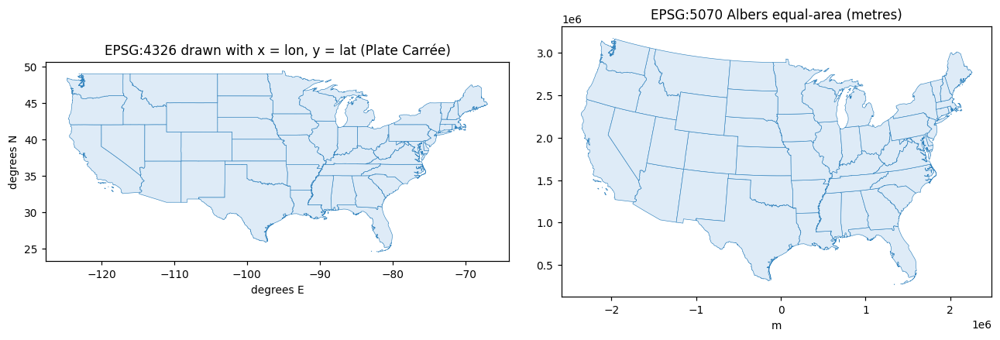

In [22]:
s48_geo = states48.to_crs(4326)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
s48_geo.plot(ax=a1, color="#deebf7", edgecolor="#3182bd", lw=0.4); a1.set_aspect(1)
a1.set_title("EPSG:4326 drawn with x = lon, y = lat (Plate Carrée)"); a1.set_xlabel("degrees E"); a1.set_ylabel("degrees N")
states48.plot(ax=a2, color="#deebf7", edgecolor="#3182bd", lw=0.4)
a2.set_title("EPSG:5070 Albers equal-area (metres)"); a2.set_xlabel("m"); a2.ticklabel_format(style="sci", scilimits=(0, 0))
plt.tight_layout(); plt.show()

### 4.4 Projection families & distortion properties (slides 32–33)
Every projection distorts something. Slide 32's table pairs surfaces (azimuthal / conic / cylindrical) with properties (equal-area / conformal / equidistant).
The cells below draw **identical 400 km geodesic circles** (Tissot-style indicatrices) and project them through five CRSs, then measure how much each circle's area changes.

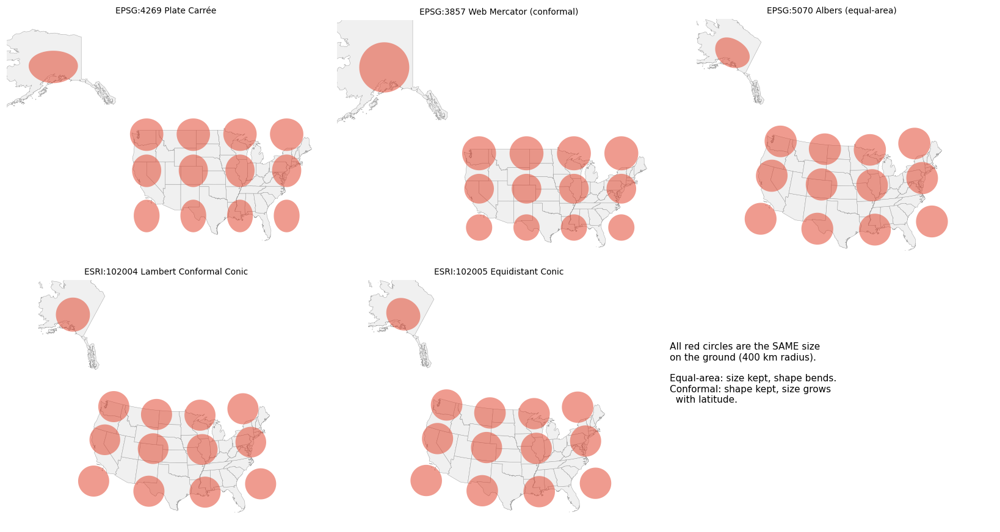

,area × at 30°N,at 48°N,at 63°N (AK)
projection,,,
EPSG:3857 Web Mercator (conformal),1.34,2.24,4.87
EPSG:5070 Albers (equal-area),1.00,1.00,1.00
ESRI:102004 Lambert Conformal Conic,1.01,1.02,1.22
ESRI:102005 Equidistant Conic,1.01,1.01,1.12


In [23]:
geod = pyproj.Geod(ellps="GRS80")


def geodesic_circle(lon, lat, r_km=400, n=90):
    az = np.linspace(0, 360, n, endpoint=False)
    lons, lats, _ = geod.fwd(np.full(n, lon), np.full(n, lat), az, np.full(n, r_km * 1000.0))
    return Polygon(zip(lons, lats))


centers = [(lo, la) for la in (30, 40, 48) for lo in (-120, -105, -90, -75)] + [(-150, 63)]
circles = gpd.GeoDataFrame({"lat": [c[1] for c in centers]}, geometry=[geodesic_circle(*c) for c in centers], crs=4269)
true_area = np.array([abs(geod.geometry_area_perimeter(g)[0]) for g in circles.geometry]) / 1e6

PROJS = {"EPSG:4269 Plate Carrée": 4269, "EPSG:3857 Web Mercator (conformal)": 3857,
         "EPSG:5070 Albers (equal-area)": 5070, "ESRI:102004 Lambert Conformal Conic": "ESRI:102004",
         "ESRI:102005 Equidistant Conic": "ESRI:102005"}
no_hi = states[states.state_abbr != "HI"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.ravel()
rows = []
for ax, (name, crs) in zip(axes, PROJS.items()):
    st, ci = no_hi.to_crs(crs), circles.to_crs(crs)
    st.plot(ax=ax, color="#f0f0f0", edgecolor="0.6", lw=0.3)
    ci.plot(ax=ax, color="#e34a33", alpha=0.55)
    xmin, ymin, xmax, ymax = ci.total_bounds; pad = 0.08 * (xmax - xmin)
    ax.set_xlim(xmin - pad, xmax + pad); ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_title(name, fontsize=9); ax.set_axis_off()
    if crs != 4269:
        ratio = (ci.area / 1e6) / true_area
        rows.append({"projection": name, "area ×  at 30°N": ratio[circles.lat == 30].mean(),
                     "at 48°N": ratio[circles.lat == 48].mean(), "at 63°N (AK)": ratio[circles.lat == 63].mean()})
axes[-1].axis("off")
axes[-1].text(0, 0.5, "All red circles are the SAME size\non the ground (400 km radius).\n\n"
              "Equal-area: size kept, shape bends.\nConformal: shape kept, size grows\n  with latitude.", fontsize=10)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index("projection").round(2))

**Size of the distortion in numbers.** The table above gives the area inflation of each circle; a ratio of 1.00 means area is kept. The next cell computes how large Alaska looks relative to Texas in each projection.

In [24]:
true = states.to_crs(6933).set_index("state_abbr").area                   # EPSG:6933 = global equal-area reference
out = {"true (equal-area)": true["AK"] / true["TX"]}
for name, crs in PROJS.items():
    if crs != 4269:
        a = states.to_crs(crs).set_index("state_abbr").area
        out[name] = a["AK"] / a["TX"]
display(pd.Series(out, name="Alaska area ÷ Texas area").round(2).to_frame())

,Alaska area ÷ Texas area
true (equal-area),2.22
EPSG:3857 Web Mercator (conformal),8.66
EPSG:5070 Albers (equal-area),2.22
ESRI:102004 Lambert Conformal Conic,2.76
ESRI:102005 Equidistant Conic,2.53


### 4.5 Choosing a CRS by scale and by task (slide 32; README 25–35′)
| Task on slide 32 | Property to keep | Example CRS |
|---|---|---|
| Population density, forest cover | **Equal-area** | EPSG:5070 (U.S.), EPSG:8857 Equal Earth (global) |
| Navigation, web maps, weather | **Conformal** | EPSG:3857 (web), Lambert Conformal Conic |
| Response time, air transport, disease spread | **Equidistant** (from a point/along lines) | ESRI:102005, Azimuthal Equidistant |

| Extent | Typical choice |
|---|---|
| Illinois / small country | State Plane (EPSG:3435 IL East) or UTM 16N (EPSG:26916) |
| Whole U.S. | EPSG:5070 Conus Albers. Filter to the lower 48 first; draw AK and HI as insets |
| Global | Equal Earth, Robinson, Winkel Tripel; check https://projectionwizard.org/ |

The next cell measures the Chicago → Los Angeles distance in each CRS and compares it with the true geodesic distance.

In [25]:
chi, la = (-87.63, 41.88), (-118.24, 34.05)
true_km = geod.inv(*chi, *la)[2] / 1000
rows = []
for name, crs in list(PROJS.items())[1:] + [("EPSG:26916 UTM 16N (local!)", 26916)]:
    p = gpd.GeoSeries(gpd.points_from_xy([chi[0], la[0]], [chi[1], la[1]]), crs=4269).to_crs(crs)
    d = p.iloc[0].distance(p.iloc[1]) / 1000
    rows.append({"CRS": name, "planar distance (km)": round(d), "error vs geodesic": f"{100 * (d / true_km - 1):+.1f}%"})
print(f"True geodesic distance: {true_km:,.0f} km")
display(pd.DataFrame(rows).set_index("CRS"))
print("A local CRS like UTM 16N (built for Illinois) is wrong for national distances, and so is Web Mercator.")

True geodesic distance: 2,809 km


,planar distance (km),error vs geodesic
CRS,,
EPSG:3857 Web Mercator (conformal),3583,+27.5%
EPSG:5070 Albers (equal-area),2790,-0.7%
ESRI:102004 Lambert Conformal Conic,2796,-0.5%
ESRI:102005 Equidistant Conic,2798,-0.4%
EPSG:26916 UTM 16N (local!),2908,+3.5%


A local CRS like UTM 16N (built for Illinois) is wrong for national distances, and so is Web Mercator.


---
## 5 · Cartographic Design (slides 34–41)

### 5.1 Same area, different purpose · three key questions (slides 35–36)
Before mapping, answer: **Who wants the map? Where will it be seen? What is its purpose?**
Slide 35's point is that the same area gives different maps for different purposes. Below, Illinois is mapped three times for three questions.

{
  "who": "GLBL 570 students + Illinois policy audience",
  "where": "Letter-size handout / slide (static, small)",
  "purpose": "Compare how Illinois counties differ in poverty, transit use, and remote work"
}


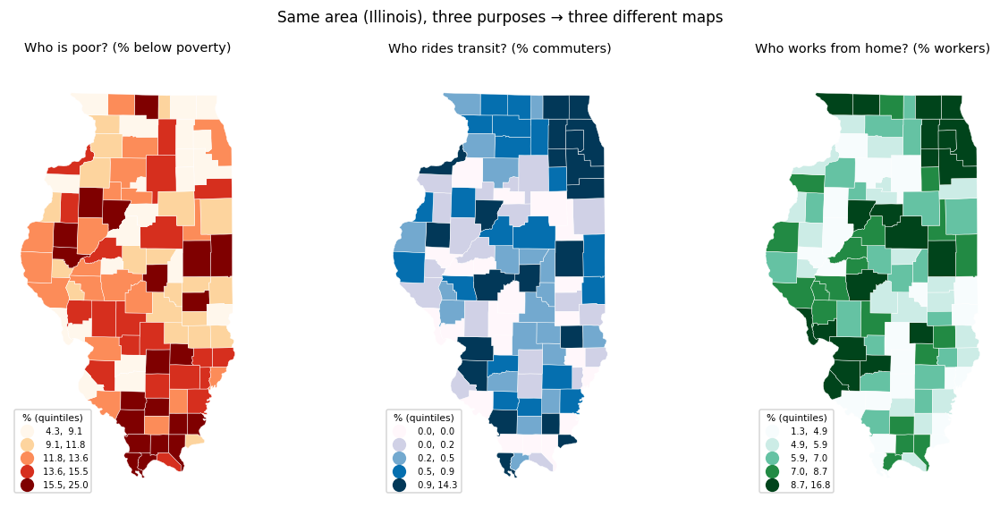

In [26]:
MAP_BRIEF = {"who": "GLBL 570 students + Illinois policy audience",
             "where": "Letter-size handout / slide (static, small)",
             "purpose": "Compare how Illinois counties differ in poverty, transit use, and remote work"}
print(json.dumps(MAP_BRIEF, indent=2))

il_m = il.to_crs(3435)                                  # NAD83 / Illinois East (ftUS): a local CRS for one state
fig, axes = plt.subplots(1, 3, figsize=(12, 5.2))
for ax, (col, cmap, ttl) in zip(axes, [("poverty_pct", "OrRd", "Who is poor? (% below poverty)"),
                                       ("transit_pct", "PuBu", "Who rides transit? (% commuters)"),
                                       ("wfh_pct", "BuGn", "Who works from home? (% workers)")]):
    il_m.plot(ax=ax, column=col, scheme="Quantiles", k=5, cmap=cmap, edgecolor="white", lw=0.3, legend=True,
              legend_kwds={"fmt": "{:.1f}", "loc": "lower left", "fontsize": 6.5, "title": "% (quintiles)", "title_fontsize": 7})
    ax.set_title(ttl, fontsize=9.5); ax.set_axis_off()
fig.suptitle("Same area (Illinois), three purposes → three different maps", fontsize=11)
plt.tight_layout(); plt.show()

### 5.2 Map design process & map elements (slides 37–38)
Slide 37's process: (1) assemble the data → (2) choose the data, analysis, and symbolisation → (3) add the title, legend, north arrow, scale bar, and labels.
Slide 38's building blocks: **title, legend, scale bar, graticule, north arrow, source / credits**. The function below adds them to a national map, with Alaska and Hawaii as insets in their own equal-area CRSs.

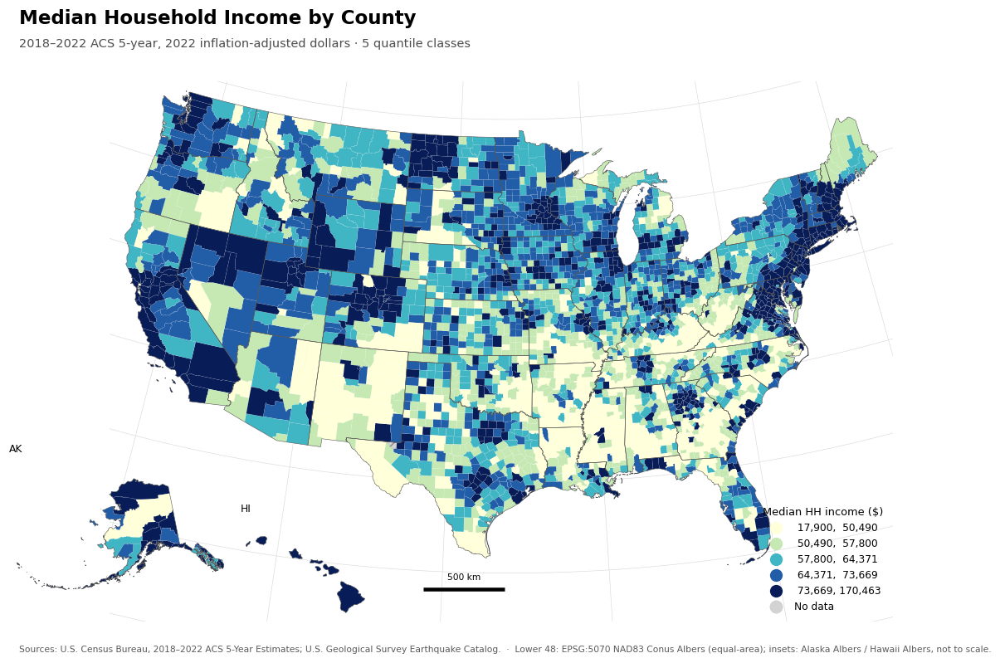

In [27]:
AK_CRS, HI_CRS = 3338, "ESRI:102007"                    # Alaska Albers, Hawaii Albers


def us_choropleth(gdf, column, bins, cmap, title, subtitle, legend_title, fmt="{:.1f}", fname=None):
    # One set of class breaks (bins) is applied to the lower 48 and both insets, so colours mean the same everywhere.
    fig = plt.figure(figsize=(11, 7.4))
    ax = fig.add_axes([0.0, 0.07, 1.0, 0.80])
    kw = dict(column=column, scheme="UserDefined", classification_kwds={"bins": list(bins)}, cmap=cmap,
              edgecolor="white", lw=0.05, missing_kwds=MISSING)
    main = gdf[~gdf.state_abbr.isin(["AK", "HI"])].to_crs(5070)
    graticule(5070).plot(ax=ax, color="0.85", lw=0.4, zorder=0)
    main.plot(ax=ax, legend=True, zorder=1, legend_kwds={"fmt": fmt, "loc": "lower right", "title": legend_title,
                                                          "fontsize": 8, "title_fontsize": 8.5, "frameon": False}, **kw)
    main.dissolve("state_abbr").boundary.plot(ax=ax, color="0.3", lw=0.35, zorder=2)
    x0, y0, x1, y1 = main.total_bounds
    ax.set_xlim(x0 - 0.02 * (x1 - x0), x1 + 0.02 * (x1 - x0)); ax.set_ylim(y0 - 0.12 * (y1 - y0), y1 + 0.02 * (y1 - y0))
    ax.set_axis_off()
    for box, st, crs in [([0.01, 0.07, 0.22, 0.26], "AK", AK_CRS), ([0.24, 0.07, 0.13, 0.14], "HI", HI_CRS)]:
        ia = fig.add_axes(box); part = gdf[gdf.state_abbr == st].to_crs(crs)
        part.plot(ax=ia, **kw); part.dissolve().boundary.plot(ax=ia, color="0.3", lw=0.35)
        if st == "AK":
            ia.set_xlim(-2.3e6, 1.6e6)                  # crop the far Aleutians
        ia.set_axis_off(); ia.set_title(st, fontsize=8, loc="left")
    add_scale_bar(ax, 500, x=0.40, y=0.06)
    fig.text(0.02, 0.955, title, fontsize=15, fontweight="bold")
    fig.text(0.02, 0.92, subtitle, fontsize=9.5, color="0.3")
    fig.text(0.02, 0.025, SOURCE + "  ·  Lower 48: EPSG:5070 NAD83 Conus Albers (equal-area); insets: Alaska Albers / Hawaii Albers, not to scale.",
             fontsize=7, color="0.35")
    if fname:
        fig.savefig(OUT / f"{fname}.png", dpi=250, bbox_inches="tight"); fig.savefig(OUT / f"{fname}.pdf", bbox_inches="tight")
    return fig


inc_bins = mc.Quantiles(counties.median_hh_income.dropna(), k=5).bins
us_choropleth(counties, "median_hh_income", inc_bins, "YlGnBu", "Median Household Income by County",
              "2018–2022 ACS 5-year, 2022 inflation-adjusted dollars · 5 quantile classes", "Median HH income ($)",
              fmt="{:,.0f}", fname="map_elements_median_income")
plt.show()

**Slide 38: "Why is there no scale bar?"** On a small-scale (national or world) map the scale is *not constant*, so one bar would mislead. Web Mercator (EPSG:3857) shows this most clearly. Its local scale factor depends on latitude:

In [28]:
merc = pyproj.Proj("EPSG:3857")
lats = [25, 35, 45, 49, 61, 71]
f = merc.get_factors([-100] * len(lats), lats)
display(pd.DataFrame({"latitude": lats, "linear scale factor": np.round(f.meridional_scale, 2),
                      "area scale factor": np.round(f.areal_scale, 2)}).set_index("latitude"))
print("A 500 km bar drawn for 25°N would be ~2.5× too short for northern Alaska (71°N) on the same Mercator map.")

,linear scale factor,area scale factor
latitude,,
25,1.10,1.22
35,1.22,1.49
45,1.41,2.00
49,1.52,2.32
61,2.06,4.25
71,3.07,9.43


A 500 km bar drawn for 25°N would be ~2.5× too short for northern Alaska (71°N) on the same Mercator map.


### 5.3 Turning data into symbols: vector (slide 39) and statistical diagrams (README 35–45′)
The same features can take different visual variables: **position** only, **size** (proportional to magnitude), and **colour value** (depth from the 3-D z coordinate).

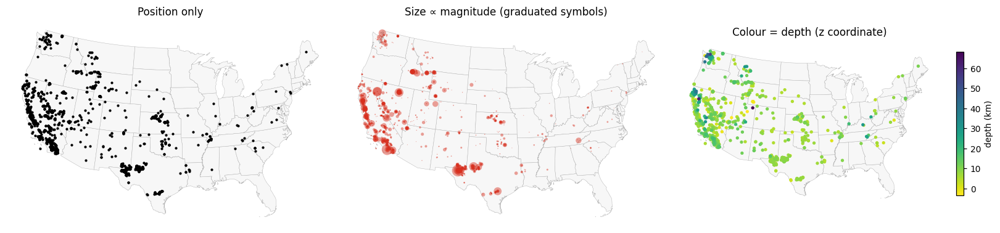

In [29]:
qp = quakes.to_crs(5070); qp = qp[qp.within(states48.union_all())]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax in axes:
    states48.plot(ax=ax, color="#f7f7f7", edgecolor="0.7", lw=0.3); ax.set_axis_off()
qp.plot(ax=axes[0], markersize=3, color="k"); axes[0].set_title("Position only")
qp.plot(ax=axes[1], markersize=(qp.mag - 2) ** 3 * 4, color="#d7301f", alpha=0.45, lw=0)
axes[1].set_title("Size ∝ magnitude (graduated symbols)")
qp.sort_values("depth_km").plot(ax=axes[2], column="depth_km", cmap="viridis_r", markersize=6, legend=True,
                                legend_kwds={"shrink": 0.6, "label": "depth (km)"})
axes[2].set_title("Colour = depth (z coordinate)")
plt.tight_layout(); plt.show()

**Pie-chart diagrams (README 35–45′, QGIS *Layer Properties → Diagrams → Pie chart*).** Filter to one state first (Illinois, `state_fips = '17'`) so the 3,144 pies don't overlap. Pie size is scaled by total (√ so that **area** ∝ count).
Option A: race composition (`race_*`). Option B: commute mode (`commute_*`).

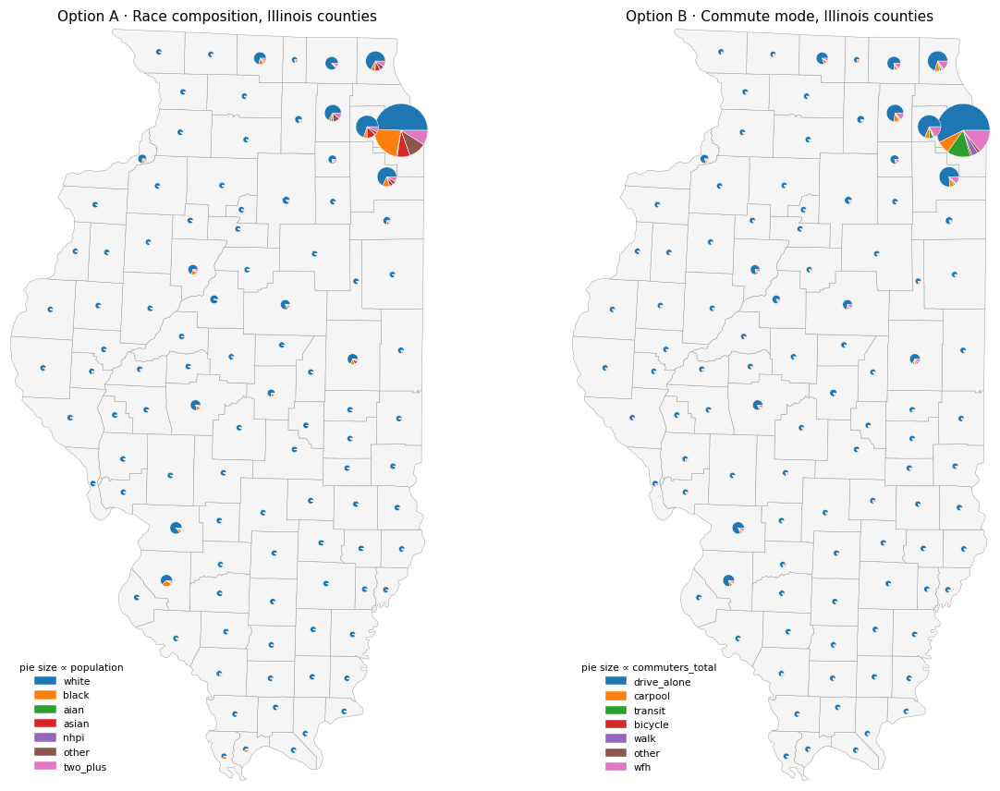

Reminder (README): pie area is not a percentage; state the size field and the class method in the map notes.


In [30]:
def pie_map(ax, gdf, fields, size_field, title, r_max=22_000):
    colors = plt.cm.tab10.colors[: len(fields)]          # fixed categorical order, never cycled
    gdf.plot(ax=ax, color="#f5f5f5", edgecolor="0.6", lw=0.3)
    pts = gdf.representative_point()
    for (_, rec), p in zip(gdf.iterrows(), pts):
        r = r_max * np.sqrt(rec[size_field] / gdf[size_field].max())
        ax.pie(rec[fields].astype(float), center=(p.x, p.y), radius=max(r, 2_500), colors=colors, frame=True,
               wedgeprops={"linewidth": 0.3, "edgecolor": "white"})
    x0, y0, x1, y1 = gdf.total_bounds
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect("equal"); ax.set_axis_off()
    ax.legend([Patch(color=c) for c in colors], [f.split("_", 1)[1] for f in fields], loc="lower left",
              fontsize=7, frameon=False, title=f"pie size ∝ {size_field}", title_fontsize=7)
    ax.set_title(title, fontsize=10)


il_utm = il.to_crs(26916)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 8))
pie_map(a1, il_utm, race, "population", "Option A · Race composition, Illinois counties")
pie_map(a2, il_utm, commute, "commuters_total", "Option B · Commute mode, Illinois counties")
plt.tight_layout(); plt.show()
print("Reminder (README): pie area is not a percentage; state the size field and the class method in the map notes.")

### 5.4 Turning data into symbols: raster renderers (slide 40)
A renderer maps cell values to colours. The four panels below use the 20 km raster from §3.3: **Stretch** (linear vs. log), **Classify**, **Unique values**, and **RGB** (three variables loaded into the R, G, and B channels).

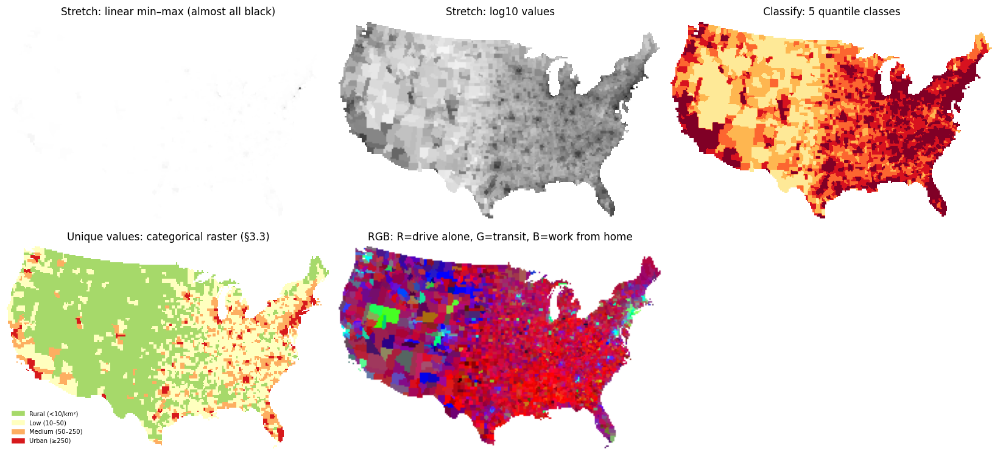

In [31]:
def stretch(a, lo=2, hi=98):
    p1, p2 = np.nanpercentile(a, [lo, hi])
    return np.clip((a - p1) / (p2 - p1), 0, 1)


share = {c: rasterize(c) / rasterize("commuters_total") for c in ["commute_drive_alone", "commute_transit", "commute_wfh"]}
rgb = np.dstack([stretch(share[c]) for c in share])
rgb = np.where(np.isfinite(rgb), rgb, 1.0)              # nodata -> white

fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes = axes.ravel()
axes[0].imshow(dens, extent=EXTENT, cmap="Greys", vmin=0, vmax=np.nanmax(dens)); axes[0].set_title("Stretch: linear min–max (almost all black)")
axes[1].imshow(np.log10(dens), extent=EXTENT, cmap="Greys"); axes[1].set_title("Stretch: log10 values")
q = mc.Quantiles(dens[np.isfinite(dens)], k=5)
axes[2].imshow(np.where(np.isfinite(dens), np.digitize(dens, q.bins[:-1]), np.nan), extent=EXTENT,
               cmap=mpl.colors.ListedColormap(plt.cm.YlOrRd(np.linspace(0.15, 1, 5)))); axes[2].set_title("Classify: 5 quantile classes")
cat_cmap = mpl.colors.ListedColormap(["white", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"])
axes[3].imshow(dens_cls, extent=EXTENT, cmap=cat_cmap, interpolation="nearest", vmin=0, vmax=4); axes[3].set_title("Unique values: categorical raster (§3.3)")
axes[3].legend([Patch(color=cat_cmap(i)) for i in range(1, 5)], LABELS, fontsize=6.5, loc="lower left", frameon=False)
axes[4].imshow(rgb, extent=EXTENT); axes[4].set_title("RGB: R=drive alone, G=transit, B=work from home")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()

### 5.5 Colour scheme: which palette carries the meaning (slide 41)
- **Quantitative** variables (house prices, temperature, rainfall) use a **sequential** ramp (one hue, light → dark), or a **diverging** ramp when there is a meaningful midpoint.
- **Qualitative** variables (building categories, regions) use a **qualitative** palette (distinct hues, no order).
- **Missing data** is shown as hatched grey with its own legend entry, never white (slide 55).

The last panel is a counter-example: a rainbow ramp on a quantitative variable.

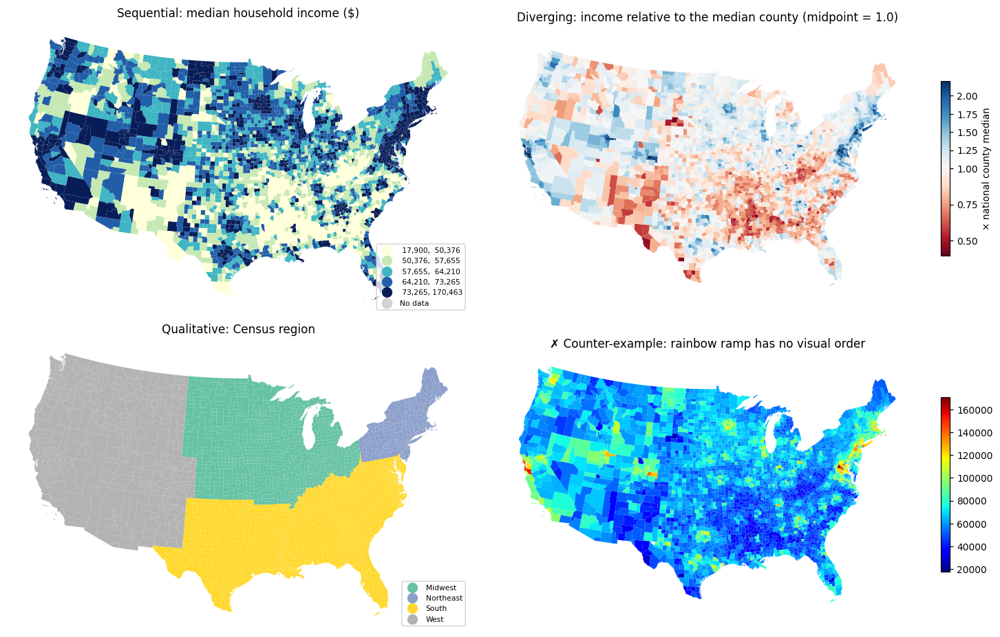

Missing (hatched) county: ['Loving County']


In [32]:
m = counties.copy()
m["income_vs_us"] = m.median_hh_income / m.median_hh_income.median()
m["region"] = m.state_abbr.map(REGION)
m48 = m[~m.state_abbr.isin(["AK", "HI"])].to_crs(5070)

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5)); axes = axes.ravel()
m48.plot(ax=axes[0], column="median_hh_income", scheme="Quantiles", k=5, cmap="YlGnBu", lw=0, legend=True,
         missing_kwds=MISSING, legend_kwds={"fmt": "{:,.0f}", "loc": "lower right", "fontsize": 7})
axes[0].set_title("Sequential: median household income ($)")
m48.plot(ax=axes[1], column="income_vs_us", cmap="RdBu", norm=mpl.colors.TwoSlopeNorm(vmin=0.4, vcenter=1, vmax=2.2),
         lw=0, legend=True, missing_kwds=MISSING, legend_kwds={"shrink": 0.6, "label": "× national county median"})
axes[1].set_title("Diverging: income relative to the median county (midpoint = 1.0)")
m48.plot(ax=axes[2], column="region", categorical=True, cmap="Set2", lw=0, legend=True,
         legend_kwds={"loc": "lower right", "fontsize": 7})
axes[2].set_title("Qualitative: Census region")
m48.plot(ax=axes[3], column="median_hh_income", cmap="jet", lw=0, legend=True, legend_kwds={"shrink": 0.6})
axes[3].set_title("✗ Counter-example: rainbow ramp has no visual order")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()
print("Missing (hatched) county:", m.loc[m.median_hh_income.isna(), "county_label"].tolist())

### 5.6 Classification: equal interval vs quantile vs natural breaks (slide 34 "classification"; README 10–25′)
**QGIS equivalent:** *Symbology → Graduated → 5 classes → Mode: Equal Interval / Quantile / Natural Breaks (Jenks).*
Record the break values for each method, then compare which counties change colour. Here natural breaks uses the exact Fisher–Jenks optimum; QGIS may sample the data for large layers, so its breaks can differ slightly.

,Equal interval,Quantile,Natural breaks (Jenks)
class 1 upper,12.4,9.3,10.0
class 2 upper,23.3,12.1,14.4
class 3 upper,34.1,14.9,19.3
class 4 upper,44.9,18.8,26.4
class 5 upper,55.8,55.8,55.8
class 1 n,1356.0,629.0,777.0
class 2 n,1543.0,629.0,1011.0
class 3 n,227.0,628.0,787.0
class 4 n,15.0,629.0,437.0
class 5 n,3.0,629.0,132.0


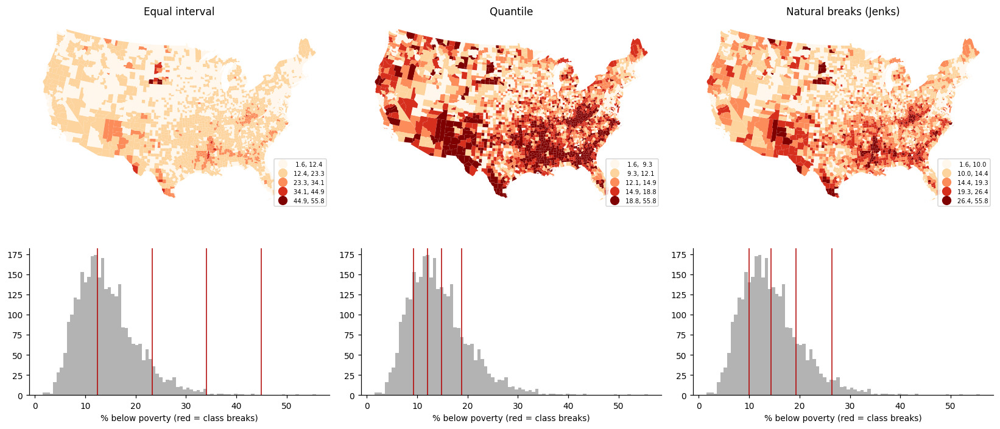

In [33]:
y = counties.poverty_pct
CLS = {"Equal interval": mc.EqualInterval(y, k=5), "Quantile": mc.Quantiles(y, k=5),
       "Natural breaks (Jenks)": mc.FisherJenks(y, k=5)}
breaks = pd.DataFrame({n: np.round(c.bins, 1) for n, c in CLS.items()}, index=[f"class {i+1} upper" for i in range(5)])
counts = pd.DataFrame({n: c.counts for n, c in CLS.items()}, index=[f"class {i+1} n" for i in range(5)])
display(pd.concat([breaks, counts]))

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), gridspec_kw={"height_ratios": [2.4, 1]})
for j, (n, c) in enumerate(CLS.items()):
    lower48.plot(ax=axes[0, j], column="poverty_pct", scheme="UserDefined", classification_kwds={"bins": list(c.bins)},
                 cmap="OrRd", lw=0, legend=True, legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "fontsize": 6.5})
    axes[0, j].set_title(n); axes[0, j].set_axis_off()
    axes[1, j].hist(y, bins=80, color="0.7")
    for b in c.bins[:-1]:
        axes[1, j].axvline(b, color="#b30000", lw=1)
    axes[1, j].set_xlabel("% below poverty (red = class breaks)"); axes[1, j].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

  Equal interval vs Quantile                :  2512 of 3144 counties change class
        Quantile vs Natural breaks (Jenks)  :  1804 of 3144 counties change class
  Equal interval vs Natural breaks (Jenks)  :  1932 of 3144 counties change class


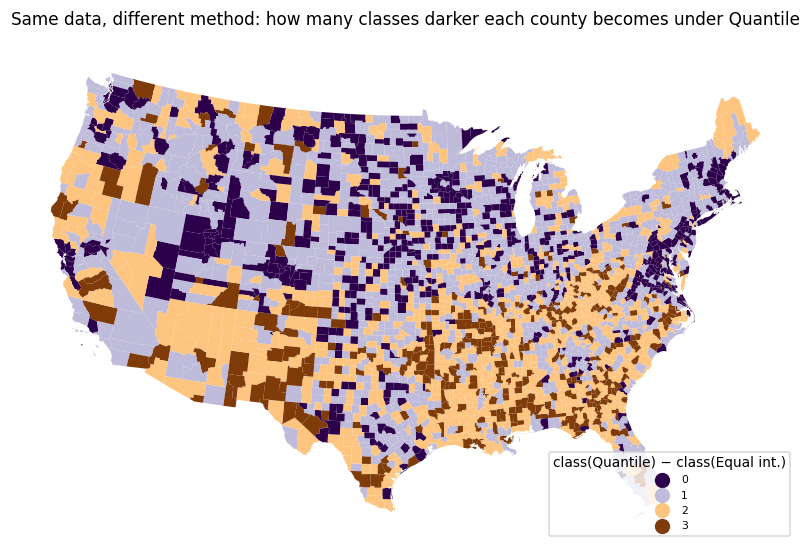

In [34]:
# Which counties change colour when only the method changes?
yb = pd.DataFrame({n: c.yb for n, c in CLS.items()}, index=counties.geoid)
for a, b in [("Equal interval", "Quantile"), ("Quantile", "Natural breaks (Jenks)"), ("Equal interval", "Natural breaks (Jenks)")]:
    print(f"{a:>16s} vs {b:<24s}: {(yb[a] != yb[b]).sum():5d} of {len(yb)} counties change class")

shift = lower48[["geoid", "geometry"]].merge((yb["Quantile"] - yb["Equal interval"]).rename("shift").reset_index(), on="geoid")
fig, ax = plt.subplots(figsize=(10, 5.8))
shift.plot(ax=ax, column="shift", categorical=True, cmap="PuOr_r", lw=0, legend=True,
           legend_kwds={"title": "class(Quantile) − class(Equal int.)", "loc": "lower right", "fontsize": 7})
ax.set_title("Same data, different method: how many classes darker each county becomes under Quantile"); ax.set_axis_off()
plt.show()

---
## 7 · Critical & Ethical Perspectives (slides 42–49)

Slide 43 lists four ways a map can "lie" without bad faith: **class breaks, colour direction, projection, normalisation**. Each one is reproduced below with this data, followed by the MAUP (slide 46), protective techniques (slide 47), and the information-loss stages (slide 49).

### 7.1 Class breaks: move a break and a place changes category

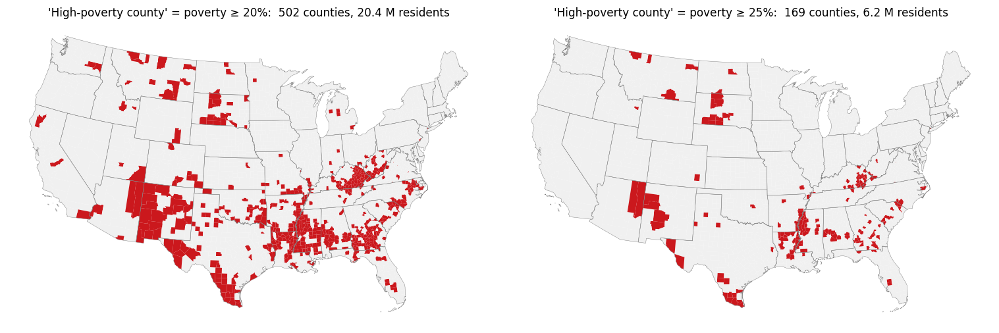

Moving the break from 20% to 25% drops 335 counties (14.3 M people) from the category.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, t in zip(axes, [20, 25]):
    hi = lower48.poverty_pct >= t
    lower48.plot(ax=ax, color=np.where(hi, "#cb181d", "#f0f0f0"), lw=0)
    states48.boundary.plot(ax=ax, color="0.5", lw=0.3)
    pop = lower48.loc[hi, "population"].sum() / 1e6
    ax.set_title(f"'High-poverty county' = poverty ≥ {t}%:  {hi.sum()} counties, {pop:.1f} M residents"); ax.set_axis_off()
plt.tight_layout(); plt.show()
moved = counties[(counties.poverty_pct >= 20) & (counties.poverty_pct < 25)]
print(f"Moving the break from 20% to 25% drops {len(moved)} counties ({moved.population.sum()/1e6:.1f} M people) from the category.")

### 7.2 Colour direction: reverse the ramp, reverse the message

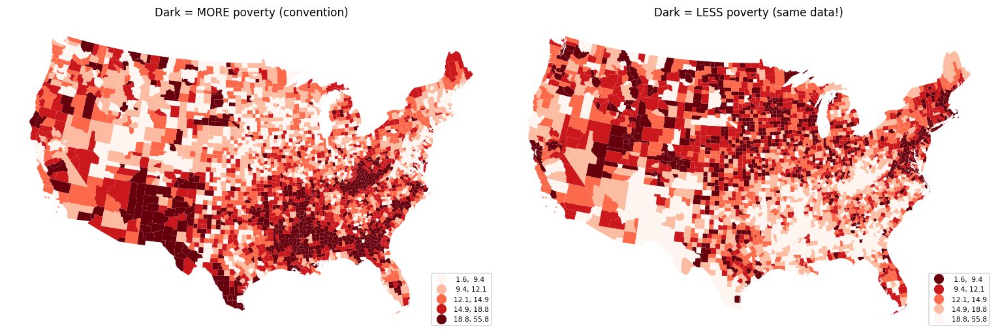

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, cmap, ttl in [(axes[0], "Reds", "Dark = MORE poverty (convention)"), (axes[1], "Reds_r", "Dark = LESS poverty (same data!)")]:
    lower48.plot(ax=ax, column="poverty_pct", scheme="Quantiles", k=5, cmap=cmap, lw=0, legend=True,
                 legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "fontsize": 7})
    ax.set_title(ttl); ax.set_axis_off()
plt.tight_layout(); plt.show()

### 7.3 Projection: inflate or shrink whole regions
How much of the map's ink does Alaska take, compared with its true share of U.S. area?

In [37]:
rows = []
for name, crs in [("true (EPSG:6933 equal-area)", 6933), ("EPSG:3857 Web Mercator", 3857), ("EPSG:5070 Albers", 5070), ("EPSG:4269 Plate Carrée", 4269)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        a = states.to_crs(crs).set_index("state_abbr").area
    rows.append({"projection": name, "Alaska share of map area": f"{100 * a['AK'] / a.sum():.1f}%",
                 "lower-48 share": f"{100 * a.drop(['AK', 'HI']).sum() / a.sum():.1f}%"})
display(pd.DataFrame(rows).set_index("projection"))

,Alaska share of map area,lower-48 share
projection,,
true (EPSG:6933 equal-area),16.3%,83.5%
EPSG:3857 Web Mercator,38.2%,61.7%
EPSG:5070 Albers,16.3%,83.5%
EPSG:4269 Plate Carrée,25.6%,74.3%


### 7.4 Normalisation: totals vs rates tell opposite stories (README 10–25′ step 4)
Compare `population` with `pop_density_km2`, and `below_poverty` (count) with `poverty_pct` (rate).

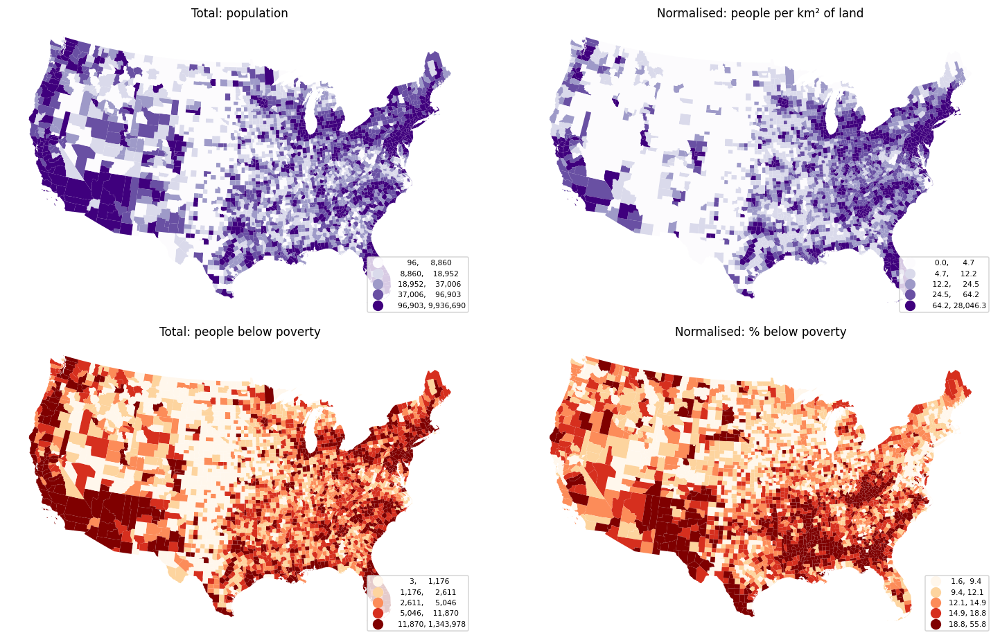

,Top 10 by count below poverty,Top 10 by % below poverty
0,"Los Angeles County, CA","Oglala Lakota County, SD"
1,"Harris County, TX","Todd County, SD"
2,"Cook County, IL","Mellette County, SD"
3,"Maricopa County, AZ","Dimmit County, TX"
4,"Kings County, NY","Corson County, SD"
5,"Miami-Dade County, FL","Ziebach County, SD"
6,"Bronx County, NY","East Carroll Parish, LA"
7,"Dallas County, TX","Presidio County, TX"
8,"Wayne County, MI","Sioux County, ND"
9,"Philadelphia County, PA","Jackson County, SD"


Overlap between the two top-10 lists: 0


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5)); axes = axes.ravel()
for ax, col, cmap, ttl in [(axes[0], "population", "Purples", "Total: population"),
                           (axes[1], "pop_density_km2", "Purples", "Normalised: people per km² of land"),
                           (axes[2], "below_poverty", "OrRd", "Total: people below poverty"),
                           (axes[3], "poverty_pct", "OrRd", "Normalised: % below poverty")]:
    lower48.plot(ax=ax, column=col, scheme="Quantiles", k=5, cmap=cmap, lw=0, legend=True,
                 legend_kwds={"fmt": "{:,.0f}" if col in ("population", "below_poverty") else "{:,.1f}",
                              "loc": "lower right", "fontsize": 7})
    ax.set_title(ttl); ax.set_axis_off()
plt.tight_layout(); plt.show()

top_n = lambda c: counties.nlargest(10, c).county_label.str.cat(counties.nlargest(10, c).state_abbr, sep=", ").tolist()
display(pd.DataFrame({"Top 10 by count below poverty": top_n("below_poverty"), "Top 10 by % below poverty": top_n("poverty_pct")}))
print("Overlap between the two top-10 lists:", len(set(top_n("below_poverty")) & set(top_n("poverty_pct"))))

### 7.5 Aggregation & the Modifiable Areal Unit Problem (slides 46, 49 stage 4)
*Same people, different units, different results.* Two effects:
- **Scale effect:** county → state → Census region.
- **Zoning effect:** the same counties grouped into two 300 km grids that differ only by an offset.

Rates must be re-computed from counts (Σ below ÷ Σ universe). Averaging county percentages is a common mistake.

In [39]:
def aggregate(df, key):
    g = df.groupby(key).agg(below=("below_poverty", "sum"), universe=("poverty_universe", "sum"),
                            wfh=("commute_wfh", "sum"), workers=("commuters_total", "sum"),
                            naive_mean_pct=("poverty_pct", "mean"))
    g["poverty_pct"] = 100 * g.below / g.universe
    g["wfh_pct"] = 100 * g.wfh / g.workers
    return g


lw = lower48.copy()
cent = lw.representative_point()
lw["region"] = lw.state_abbr.map(REGION)
lw["grid_a"] = (cent.x // 300_000).astype(int).astype(str) + "_" + (cent.y // 300_000).astype(int).astype(str)
lw["grid_b"] = ((cent.x + 150_000) // 300_000).astype(int).astype(str) + "_" + ((cent.y + 150_000) // 300_000).astype(int).astype(str)

rows = []
for level in ["geoid", "grid_a", "grid_b", "state_abbr", "region"]:
    g = aggregate(lw, level)
    rows.append({"unit": level, "n units": len(g), "poverty % range": f"{g.poverty_pct.min():.1f} – {g.poverty_pct.max():.1f}",
                 "corr(poverty %, WFH %)": round(g[["poverty_pct", "wfh_pct"]].corr().iloc[0, 1], 2)})
display(pd.DataFrame(rows).set_index("unit"))

st = aggregate(lw, "state_abbr")
print(f"Illinois poverty: correct (Σbelow/Σuniverse) = {st.loc['IL', 'poverty_pct']:.1f}%  vs  naive mean of county % = {st.loc['IL', 'naive_mean_pct']:.1f}%")

,n units,poverty % range,"corr(poverty %, WFH %)"
unit,,,
geoid,3109,1.6 – 55.8,-0.37
grid_a,111,6.9 – 24.6,-0.55
grid_b,113,7.5 – 28.0,-0.51
state_abbr,49,7.3 – 19.2,-0.45
region,4,11.6 – 13.8,-0.50


Illinois poverty: correct (Σbelow/Σuniverse) = 11.8%  vs  naive mean of county % = 12.6%


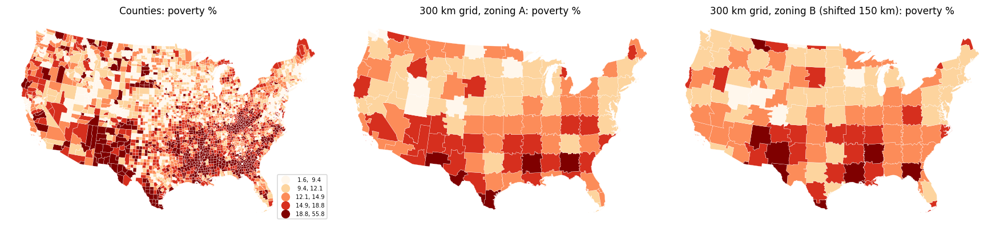

Ecological fallacy: the correlation in the table above changes with the unit, so county-level patterns say nothing certain about individuals.


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
bins = list(mc.Quantiles(lower48.poverty_pct, k=5).bins)
for ax, level, ttl in [(axes[0], "geoid", "Counties"), (axes[1], "grid_a", "300 km grid, zoning A"), (axes[2], "grid_b", "300 km grid, zoning B (shifted 150 km)")]:
    g = lw.dissolve(level)[["geometry"]].join(aggregate(lw, level)["poverty_pct"])
    g.plot(ax=ax, column="poverty_pct", scheme="UserDefined", classification_kwds={"bins": bins}, cmap="OrRd",
           edgecolor="white", lw=0.2, legend=(level == "geoid"), legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "fontsize": 6.5})
    ax.set_title(f"{ttl}: poverty %"); ax.set_axis_off()
plt.tight_layout(); plt.show()
print("Ecological fallacy: the correlation in the table above changes with the unit, so county-level patterns say nothing certain about individuals.")

### 7.6 Ethics: precision can be a threat, so protect points before publishing (slide 47)
Earthquakes are not sensitive, but the same techniques apply to refugee camps, shelters, or patient addresses. The cells below compare **exact points**, **jittered points** (random 5–25 km "donut" displacement), and **aggregation** to coarser units (counts per hexagon).

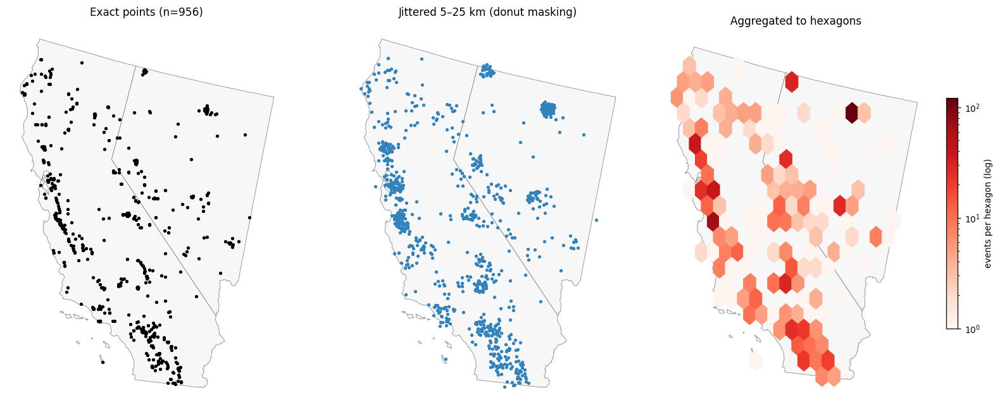

Ask before publishing: Who is on this map, and did they consent? Who could be harmed? Does aggregation keep the pattern?


In [41]:
ca = qp[qp.within(states48[states48.state_abbr.isin(["CA", "NV"])].union_all())].copy()
ang = RNG.uniform(0, 2 * np.pi, len(ca)); dist = RNG.uniform(5_000, 25_000, len(ca))
jit = ca.copy(); jit["geometry"] = gpd.points_from_xy(ca.geometry.x + dist * np.cos(ang), ca.geometry.y + dist * np.sin(ang), crs=5070)
base = states48[states48.state_abbr.isin(["CA", "NV"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax in axes:
    base.plot(ax=ax, color="#f7f7f7", edgecolor="0.5", lw=0.5); ax.set_axis_off()
ca.plot(ax=axes[0], markersize=6, color="k"); axes[0].set_title(f"Exact points (n={len(ca)})")
jit.plot(ax=axes[1], markersize=6, color="#3182bd"); axes[1].set_title("Jittered 5–25 km (donut masking)")
hb = axes[2].hexbin(ca.geometry.x, ca.geometry.y, gridsize=18, mincnt=1, cmap="Reds", bins="log")
fig.colorbar(hb, ax=axes[2], shrink=0.6, label="events per hexagon (log)"); axes[2].set_title("Aggregated to hexagons")
plt.tight_layout(); plt.show()
print("Ask before publishing: Who is on this map, and did they consent? Who could be harmed? Does aggregation keep the pattern?")

### 7.7 Eight places a map loses information (slide 49): checks on this data
| Stage | What this data pack loses | Check below |
|---|---|---|
| 2 Collection | ACS is a sample, and margins of error were dropped from the pack | small-population counties = least reliable estimates |
| 3 Encoding | "not available" stored as −666,666,666 | fixed in §3.6 |
| 4 Aggregation | county units hide within-county variation | §7.5 |
| 5 Scale | 1:5,000,000 generalised boundaries | area error vs county size (next cell) |
| 7 Classification | no default symbol for "we do not know" | hatched "No data" in §5.5 |

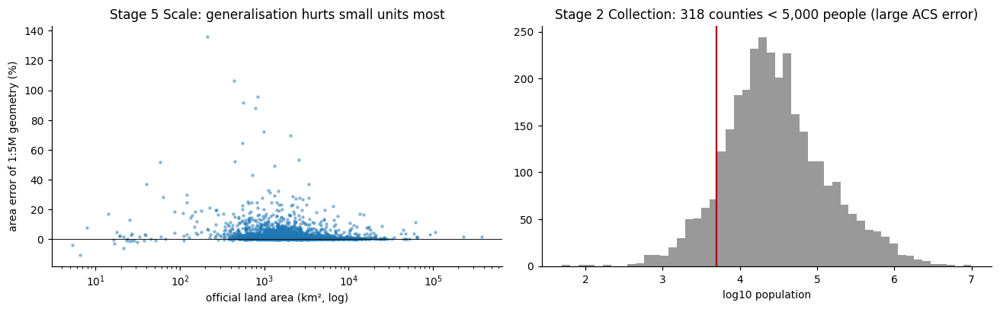

Median |area error|: 1.2 % ; worst: ['Grand Isle County', 'VT'] 136%


In [42]:
# Cartographic boundaries are clipped to the shoreline, so compare with LAND area (not land + water).
cmp["pct_area_error"] = 100 * (cmp.area_km2_albers / cmp.land_km2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].scatter(cmp.land_km2, cmp.pct_area_error, s=4, alpha=0.4)
axes[0].set_xscale("log"); axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xlabel("official land area (km², log)"); axes[0].set_ylabel("area error of 1:5M geometry (%)")
axes[0].set_title("Stage 5 Scale: generalisation hurts small units most")
axes[1].hist(np.log10(counties.population), bins=50, color="0.6")
axes[1].axvline(np.log10(5_000), color="#b30000"); axes[1].set_xlabel("log10 population")
axes[1].set_title(f"Stage 2 Collection: {(counties.population < 5000).sum()} counties < 5,000 people (large ACS error)")
for a in axes: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print("Median |area error|:", round(cmp.pct_area_error.abs().median(), 1), "% ; worst:",
      cmp.loc[cmp.pct_area_error.abs().idxmax(), ["county_label", "state_abbr"]].tolist(), f"{cmp.pct_area_error.abs().max():.0f}%")

---
## 8 · Discussion & AI Engagement (slides 50–53)
These slides are discussion only, with no data operations. Evidence from this notebook that you can bring to the small groups:
- **Kwan / feminist GIS:** what is *not* in this pack (care work, fear, mobility constraints)? The ACS commute categories record only the *main* mode of a *paid* worker (§5.3).
- **Snow, revisited:** §2.4 reads the earthquake points like Snow's pump map. Whose experience is missing when a point stands in for a person?
- **Visibility vs exposure:** §7.6 shows that jittering and aggregation keep the pattern while removing exact locations.

---
## 9 · Lab & Milestone (slides 54–59)

### 9.1 The AI map brief (slide 55), filled in for this dataset
Slide 55's prompt template, completed with decisions this notebook can defend. The final map in §9.2 follows it, and the code **prints the class breaks before rendering**, as the template requires.

In [43]:
BRIEF = {
    "purpose / audience / medium": "Show where poverty concentrates, for GLBL 570 classmates, on a letter-size slide",
    "message": "High poverty is regionally clustered (Delta, Appalachia, border, reservations), not random",
    "layer": "us_counties_acs2022, U.S. Census Bureau ACS 2018–22, polygon, EPSG:4269",
    "unit of analysis": "county (do not change it)",
    "variable": "poverty_pct = below_poverty / poverty_universe (already normalised: a rate, not a count)",
    "classification": "Natural breaks (Fisher–Jenks), 5 classes",
    "colour": "sequential OrRd, colour-blind safe, dark = high",
    "missing data": "hatched grey with its own legend entry",
    "projection": "EPSG:5070 Conus Albers (equal-area, because colour fills area); AK/HI insets in their own Albers",
    "marginalia": "title, subtitle, source, CRS note, scale bar; no north arrow (north rotates across a conic map)",
    "do not": "invent data to fill gaps",
}
for k, v in BRIEF.items():
    print(f"- {k}: {v}")

final_bins = mc.FisherJenks(counties.poverty_pct.dropna(), k=5).bins
print("\nBreak values BEFORE rendering:", np.round(final_bins, 1))

- purpose / audience / medium: Show where poverty concentrates, for GLBL 570 classmates, on a letter-size slide
- message: High poverty is regionally clustered (Delta, Appalachia, border, reservations), not random
- layer: us_counties_acs2022, U.S. Census Bureau ACS 2018–22, polygon, EPSG:4269
- unit of analysis: county (do not change it)
- variable: poverty_pct = below_poverty / poverty_universe (already normalised: a rate, not a count)
- classification: Natural breaks (Fisher–Jenks), 5 classes
- colour: sequential OrRd, colour-blind safe, dark = high
- missing data: hatched grey with its own legend entry
- projection: EPSG:5070 Conus Albers (equal-area, because colour fills area); AK/HI insets in their own Albers
- marginalia: title, subtitle, source, CRS note, scale bar; no north arrow (north rotates across a conic map)
- do not: invent data to fill gaps

Break values BEFORE rendering: [10.  14.4 19.3 26.4 55.8]


### 9.2 Workshop: final thematic map + export (slide 57: 0–40′)
Load → join (§3.4) → choropleth → ≥2 classification schemes (§5.6) → legend, colours, projection → **export**.

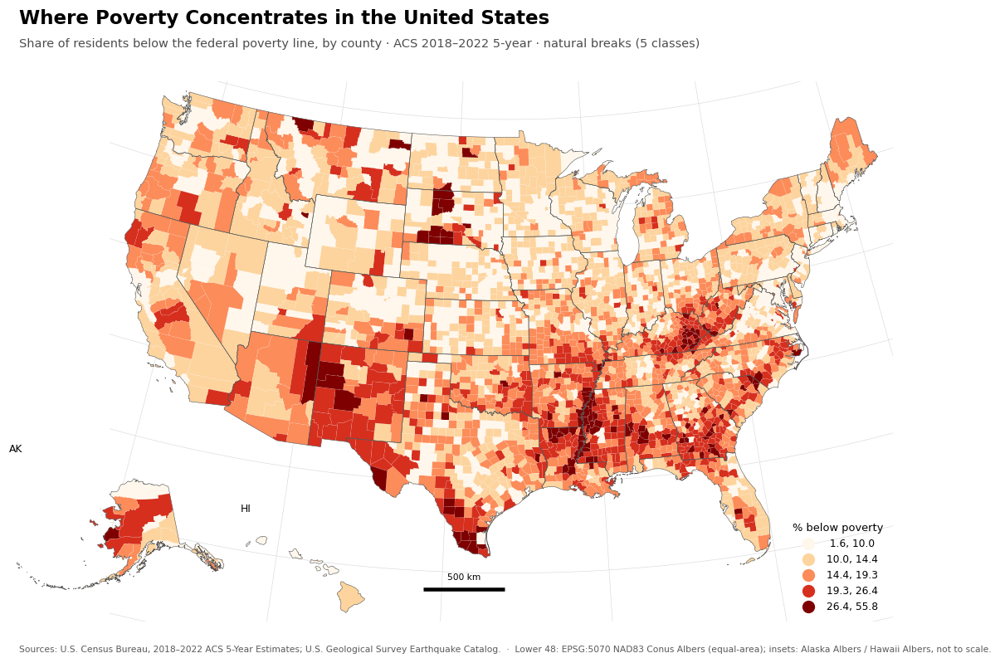

Exported: ['final_map_poverty_pct.pdf', 'final_map_poverty_pct.png']


In [44]:
us_choropleth(counties, "poverty_pct", final_bins, "OrRd",
              "Where Poverty Concentrates in the United States",
              "Share of residents below the federal poverty line, by county · ACS 2018–2022 5-year · natural breaks (5 classes)",
              "% below poverty", fname="final_map_poverty_pct")
plt.show()
print("Exported:", sorted(p.name for p in OUT.glob("final_map_poverty_pct.*")))

### 9.3 Spatial statistics: join attributes by location (summary) (README 45–60′)
**QGIS equivalent:** *Processing Toolbox → Join attributes by location (summary)*. Input = counties, join = earthquakes, predicate = *intersects*, summaries = count / mean / max of `mag`.
Then the count is normalised to **events per 10,000 km²** of county area.

In [45]:
pairs = gpd.sjoin(quakes[["mag", "geometry"]], counties[["geoid", "geometry"]], predicate="intersects", how="inner")
summary = pairs.groupby("geoid").mag.agg(mag_count="count", mag_mean="mean", mag_max="max")
eq = counties.merge(summary, on="geoid", how="left")
eq["mag_count"] = eq.mag_count.fillna(0).astype(int)                      # no quake = 0, a real value (not missing)
eq["eq_per_10k_km2"] = eq.mag_count / (eq.land_km2 + eq.water_km2) * 1e4

print(f"Points joined: {len(pairs)} (source has {len(quakes)}; {pairs.index.duplicated().sum()} points touch >1 county)")
print(f"Counties with ≥1 event: {(eq.mag_count > 0).sum()} of {len(eq)}")
display(eq.nlargest(8, "mag_count")[["county_label", "state_abbr", "mag_count", "mag_mean", "mag_max", "eq_per_10k_km2"]].round(2))
display(eq.nlargest(8, "eq_per_10k_km2")[["county_label", "state_abbr", "mag_count", "eq_per_10k_km2"]].round(2))
eq.to_file(OUT / "lab_outputs.gpkg", layer="counties_eq_summary_2025")

Points joined: 3290 (source has 3754; 0 points touch >1 county)
Counties with ≥1 event: 263 of 3144


,county_label,state_abbr,mag_count,mag_mean,mag_max,eq_per_10k_km2
3099,Matanuska-Susitna Borough,AK,273,2.88,6.0,41.72
1128,Culberson County,TX,262,2.84,5.4,265.34
788,Kenai Peninsula Borough,AK,248,2.86,5.4,38.73
845,Hawaii County,HI,134,2.87,4.4,101.72
1866,Elko County,NV,127,3.02,4.8,28.50
2030,Denali Borough,AK,106,2.92,4.1,32.31
347,Custer County,ID,100,2.94,4.3,78.18
384,Yukon-Koyukuk Census Area,AK,82,2.93,5.2,2.14


,county_label,state_abbr,mag_count,eq_per_10k_km2
1128,Culberson County,TX,262,265.34
1548,Contra Costa County,CA,46,220.93
1401,San Benito County,CA,70,194.37
41,Martin County,TX,45,189.74
2058,Loving County,TX,26,148.38
2060,Broomfield County,CO,1,115.09
1497,Sonoma County,CA,49,107.05
2774,Alameda County,CA,22,103.44


**Why do some points not join?** The README says the points were clipped to the county boundaries, yet the *intersects* join leaves some unmatched. The cell below measures how far those points lie from the nearest county polygon.

In [46]:
lost = quakes[~quakes.index.isin(pairs.index)]
near = gpd.sjoin_nearest(lost.to_crs(5070), counties[["geoid", "state_abbr", "geometry"]].to_crs(5070), distance_col="dist_m")
print(f"{len(lost)} unjoined events; by state of nearest county: {near.state_abbr.value_counts().to_dict()}")
print(f"distance to nearest county polygon: median {near.dist_m.median()/1000:.1f} km, max {near.dist_m.max()/1000:.1f} km")
print("They are real events in coastal water (Alaska and Hawaii shores) that fall outside the generalised 1:5,000,000")
print("shoreline (slide 49, stage 5 'Scale'). An 'intersects' join silently drops them. Report this or use a nearest join")
print("with a stated distance limit, but do not hide it.")

464 unjoined events; by state of nearest county: {'AK': 425, 'HI': 21, 'CA': 17, 'ME': 1}
distance to nearest county polygon: median 3.8 km, max 43.6 km
They are real events in coastal water (Alaska and Hawaii shores) that fall outside the generalised 1:5,000,000
shoreline (slide 49, stage 5 'Scale'). An 'intersects' join silently drops them. Report this or use a nearest join
with a stated distance limit, but do not hide it.


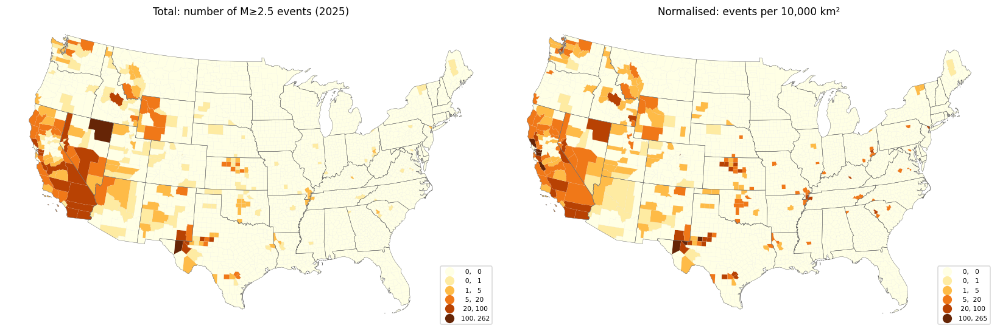

Alaska holds 36% of all joined events, but the lower-48 map above cannot show it.
Selection bias: one year (2025) and a M≥2.5 cut-off; this is not long-term seismic hazard (README).


In [47]:
eq48 = eq[~eq.state_abbr.isin(["AK", "HI"])].to_crs(5070)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, bins, ttl in [(axes[0], "mag_count", [0, 1, 5, 20, 100, eq48.mag_count.max()], "Total: number of M≥2.5 events (2025)"),
                           (axes[1], "eq_per_10k_km2", [0, 1, 5, 20, 100, eq48.eq_per_10k_km2.max()], "Normalised: events per 10,000 km²")]:
    eq48.plot(ax=ax, column=col, scheme="UserDefined", classification_kwds={"bins": bins}, cmap="YlOrBr",
              edgecolor="0.85", lw=0.05, legend=True, legend_kwds={"fmt": "{:.0f}", "loc": "lower right", "fontsize": 7})
    states48.boundary.plot(ax=ax, color="0.4", lw=0.3); ax.set_title(ttl); ax.set_axis_off()
plt.tight_layout(); plt.show()
ak_share = eq.loc[eq.state_abbr == "AK", "mag_count"].sum() / eq.mag_count.sum()
print(f"Alaska holds {100*ak_share:.0f}% of all joined events, but the lower-48 map above cannot show it.")
print("Selection bias: one year (2025) and a M≥2.5 cut-off; this is not long-term seismic hazard (README).")

### 9.4 Optional: Global Moran's I and LISA for `poverty_pct` (README "further analysis")
This is the formal test of slide 11's "poverty clusters". It uses **queen contiguity** (counties sharing a border or a corner) on the lower 48, row-standardised weights, and 999 permutations.
PySAL (`libpysal`/`esda`) is not installed here, so the statistics are computed directly with numpy/scipy. The formulas match PySAL's. GeoDa can read `us_census_acs2022.gpkg` to cross-check.

In [48]:
from scipy import sparse

c48 = lower48[["geoid", "county_label", "state_abbr", "poverty_pct", "geometry"]].reset_index(drop=True)
nb = gpd.sjoin(c48[["geometry"]], c48[["geometry"]], predicate="intersects")
nb = nb[nb.index != nb.index_right]
islands = sorted(set(c48.index) - set(nb.index))
print("Counties with no neighbours (dropped):", c48.loc[islands, "county_label"].str.cat(c48.loc[islands, "state_abbr"], sep=", ").tolist())
keep = np.setdiff1d(c48.index, islands)
c48 = c48.loc[keep].reset_index(drop=True)
remap = {old: new for new, old in enumerate(keep)}
i, j = nb.index.map(remap), nb.index_right.map(remap)
ok = ~(pd.isna(i) | pd.isna(j))
Wb = sparse.csr_matrix((np.ones(ok.sum()), (np.asarray(i[ok], int), np.asarray(j[ok], int))), shape=(len(c48),) * 2)
k = np.asarray(Wb.sum(1)).ravel()
W = sparse.diags(1 / k) @ Wb                                   # row-standardised

z = c48.poverty_pct.values - c48.poverty_pct.mean()
n = len(z)
moran_I = (z @ (W @ z)) / (z @ z)                              # S0 = n under row standardisation
perms = np.column_stack([RNG.permutation(z) for _ in range(999)])
I_sim = np.einsum("ij,ij->j", perms, W @ perms) / (perms ** 2).sum(0)
p_sim = (np.sum(I_sim >= moran_I) + 1) / 1000
print(f"Global Moran's I = {moran_I:.3f}  (E[I] = {-1/(n-1):.4f}),  pseudo p = {p_sim:.3f}  (n = {n}, mean neighbours = {k.mean():.1f})")

Counties with no neighbours (dropped): ['Nantucket County, MA', 'San Juan County, WA']
Global Moran's I = 0.496  (E[I] = -0.0003),  pseudo p = 0.001  (n = 3107, mean neighbours = 5.8)


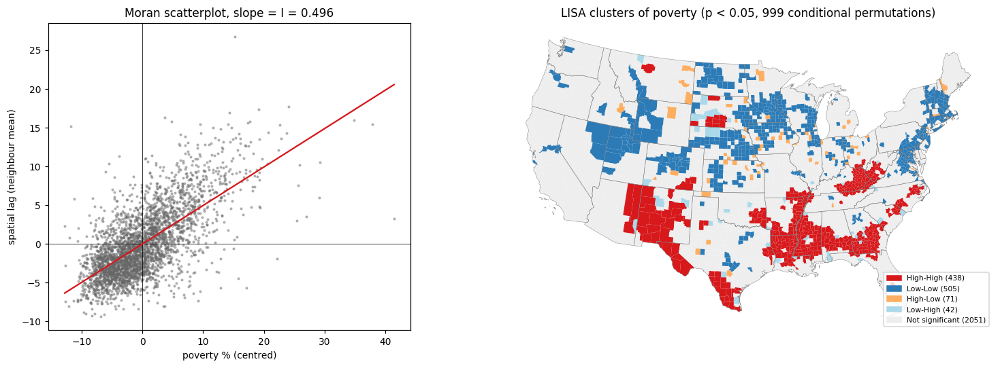

Caveat: p < 0.05 for ~3,100 local tests with no multiple-testing correction; expect some false positives.


In [49]:
# Local Moran (LISA) with conditional permutation. Neighbour values are drawn with replacement
# from the other n-1 counties, an approximation that is negligible here because k << n.
m2 = (z @ z) / n
lag = W @ z
Ii = z * lag / m2
kk = np.asarray(Wb.sum(1)).ravel().astype(int)
p_local = np.empty(n)
for idx in range(n):
    draw = RNG.integers(0, n - 1, size=(999, kk[idx]))
    draw[draw >= idx] += 1                                     # skip the county itself
    sim = z[idx] * z[draw].mean(1) / m2
    larger = (sim >= Ii[idx]).sum()
    p_local[idx] = (min(larger, 999 - larger) + 1) / 1000

quad = np.select([(z > 0) & (lag > 0), (z < 0) & (lag < 0), (z > 0) & (lag < 0), (z < 0) & (lag > 0)], ["High-High", "Low-Low", "High-Low", "Low-High"])
c48["lisa"] = np.where(p_local < 0.05, quad, "Not significant")
LISA_COL = {"High-High": "#d7191c", "Low-Low": "#2c7bb6", "High-Low": "#fdae61", "Low-High": "#abd9e9", "Not significant": "#eeeeee"}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
a1.scatter(z, lag, s=3, alpha=0.4, color="0.4"); a1.axhline(0, color="k", lw=0.5); a1.axvline(0, color="k", lw=0.5)
b = np.polyfit(z, lag, 1)[0]; xs = np.array([z.min(), z.max()]); a1.plot(xs, b * xs, color="#d7191c")
a1.set_xlabel("poverty % (centred)"); a1.set_ylabel("spatial lag (neighbour mean)"); a1.set_title(f"Moran scatterplot, slope = I = {b:.3f}")
c48.plot(ax=a2, color=c48.lisa.map(LISA_COL), lw=0); states48.boundary.plot(ax=a2, color="0.5", lw=0.3)
a2.legend([Patch(color=v) for v in LISA_COL.values()], [f"{k_} ({(c48.lisa == k_).sum()})" for k_ in LISA_COL], loc="lower right", fontsize=7)
a2.set_title("LISA clusters of poverty (p < 0.05, 999 conditional permutations)"); a2.set_axis_off()
plt.tight_layout(); plt.show()
print("Caveat: p < 0.05 for ~3,100 local tests with no multiple-testing correction; expect some false positives.")
c48.drop(columns="geometry").to_csv(OUT / "lisa_poverty_pct.csv", index=False)

### 9.5 Optional extension: an open-source point layer over your map (slide 56)
Slide 56 suggests loading an OSINT point dataset over your map (UNHCR camps, ACLED events). The USGS catalogue is open data with the same structure, so it is overlaid here on the poverty map.
Policy question to ask: *which high-poverty places also face hazard exposure?* Remember slide 47: for camps or conflict events, aggregate before you publish.

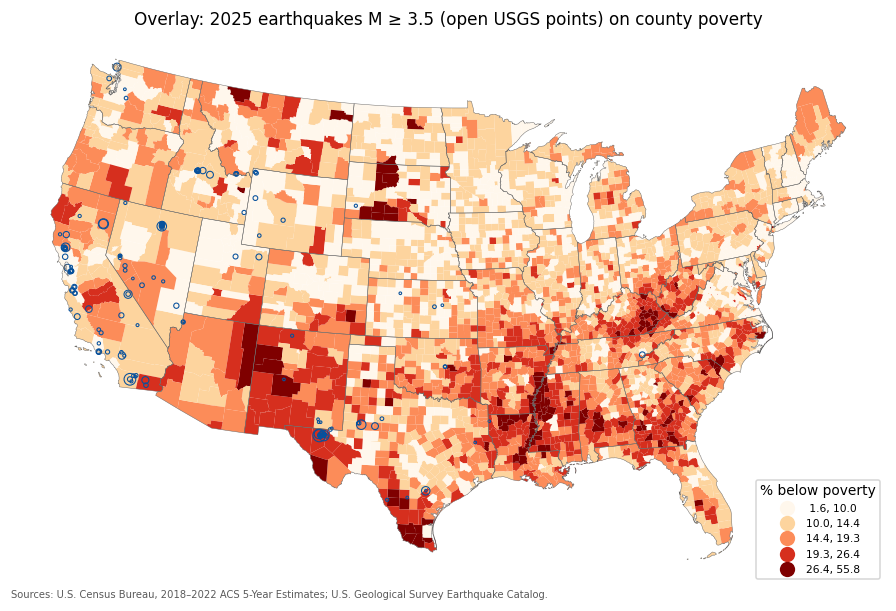

14 counties are in the top two poverty classes AND had an M≥3.5 event in 2025:
             county_label state_abbr  poverty_pct  mag_max
         Culberson County         TX         22.2      5.4
Yukon-Koyukuk Census Area         AK         22.9      5.2
            Karnes County         TX         21.0      4.6
          Imperial County         CA         21.1      4.3
            Fresno County         CA         19.5      4.2
         Nome Census Area         AK         21.1      4.0
            Reeves County         TX         21.0      3.7
          Maverick County         TX         23.4      3.6
        Rio Arriba County         NM         21.8      3.6
       Bethel Census Area         AK         25.3      3.5


In [50]:
fig, ax = plt.subplots(figsize=(11, 6.5))
lower48.plot(ax=ax, column="poverty_pct", scheme="UserDefined", classification_kwds={"bins": list(final_bins)},
             cmap="OrRd", lw=0, legend=True, legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "title": "% below poverty", "fontsize": 7})
states48.boundary.plot(ax=ax, color="0.4", lw=0.3)
qp[qp.mag >= 3.5].plot(ax=ax, markersize=(qp.mag[qp.mag >= 3.5] - 3) ** 2 * 12, facecolor="none", edgecolor="#08519c", lw=0.7)
ax.set_title("Overlay: 2025 earthquakes M ≥ 3.5 (open USGS points) on county poverty"); ax.set_axis_off(); add_source(ax)
plt.show()

hp = eq[(eq.poverty_pct >= final_bins[2]) & (eq.mag_max >= 3.5)]
print(f"{len(hp)} counties are in the top two poverty classes AND had an M≥3.5 event in 2025:")
print(hp.sort_values("mag_max", ascending=False)[["county_label", "state_abbr", "poverty_pct", "mag_max"]].head(10).round(1).to_string(index=False))

### 9.6 Workflow memo & milestone (slide 57: 40–60′)
The milestone asks for: a finished thematic map (§9.2), **one design choice**, **one ethical consideration**, and **one AI suggestion**. The cell below writes a pre-filled memo skeleton (facts from this run) to `outputs/workflow_memo.md`. The reasoning sections are left for you to write.

In [51]:
memo = f'''# Workflow memo: {BRIEF["message"]}

## Data
- us_counties_acs2022 ({len(counties)} counties, EPSG:4269), ACS 2018–2022 5-year; joined from CSV on GEOID = geoid ({len(joined)} rows, 0 unmatched)
- usgs_earthquakes_2025_m25 ({len(quakes)} points, reprojected EPSG:4979 → 4269)
- Data fix: 1 county with median_hh_income = -666,666,666 set to No data

## Steps
1. Join CSV attributes (GEOID read as text; integer keys would drop {(~matched).sum()} counties)
2. Classified poverty_pct: equal interval / quantile / natural breaks (breaks in §5.6)
3. Projected to EPSG:5070 (equal-area) with AK/HI insets
4. Final map: natural breaks {np.round(final_bins, 1).tolist()}
5. Spatial join: earthquakes → counties (count/mean/max mag), per 10,000 km²
6. Global Moran's I for poverty_pct = {moran_I:.3f} (pseudo p = {p_sim:.3f})

## Design choice and why
- (write: e.g. natural breaks vs quantile; what changed on the map — {(yb["Quantile"] != yb["Natural breaks (Jenks)"]).sum()} counties change class)

## Ethical consideration
- (write: e.g. 20% vs 25% "high-poverty" threshold moves {len(moved)} counties; stigma of labelling places)

## AI suggestion captured
- (paste one suggestion from your AI map brief and whether you accepted it)

{SOURCE}
'''
(OUT / "workflow_memo.md").write_text(memo)
print(memo)

# Workflow memo: High poverty is regionally clustered (Delta, Appalachia, border, reservations), not random

## Data
- us_counties_acs2022 (3144 counties, EPSG:4269), ACS 2018–2022 5-year; joined from CSV on GEOID = geoid (3144 rows, 0 unmatched)
- usgs_earthquakes_2025_m25 (3754 points, reprojected EPSG:4979 → 4269)
- Data fix: 1 county with median_hh_income = -666,666,666 set to No data

## Steps
1. Join CSV attributes (GEOID read as text; integer keys would drop 318 counties)
2. Classified poverty_pct: equal interval / quantile / natural breaks (breaks in §5.6)
3. Projected to EPSG:5070 (equal-area) with AK/HI insets
4. Final map: natural breaks [10.0, 14.4, 19.3, 26.4, 55.8]
5. Spatial join: earthquakes → counties (count/mean/max mag), per 10,000 km²
6. Global Moran's I for poverty_pct = 0.496 (pseudo p = 0.001)

## Design choice and why
- (write: e.g. natural breaks vs quantile; what changed on the map — 1804 counties change class)

## Ethical consideration
- (write: e.g. 20% vs 2

In [52]:
print("Files written to", OUT.resolve())
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(OUT)):45s} {p.stat().st_size/1024:8.1f} kB")

Files written to /u/wz53/Global_study_experiments/outputs
  earthquakes_table.csv                            133.5 kB
  final_map_poverty_pct.pdf                       2351.6 kB
  final_map_poverty_pct.png                       1133.9 kB
  il_counties.geojson                              230.7 kB
  il_counties.gpkg                                 224.0 kB
  il_counties.kml                                  248.1 kB
  lab_outputs.gpkg                                5424.0 kB
  lisa_poverty_pct.csv                             170.3 kB
  map_elements_median_income.pdf                  2352.2 kB
  map_elements_median_income.png                  1203.3 kB
  metadata_record.json                               1.6 kB
  pop_density_20km_epsg5070.tif                    132.2 kB
  shapefile/il_counties.cpg                          0.0 kB
  shapefile/il_counties.dbf                        116.7 kB
  shapefile/il_counties.prj                          0.2 kB
  shapefile/il_counties.shp               